# 🛡️ Biometric Stress Detection — Violence Against Women Safety App
## WESAD Dataset · HRV-Based Stress & Danger Level Pipeline
### Classification · Clustering · Regression · Deep Learning · Explainability

---

### What this notebook does
Uses the **WESAD** (Wearable Stress and Affect Detection) dataset to train models that
detect **physiological stress** and predict a **danger/threat level** from heart rate
variability and biometric signals from a wearable device.

The models are saved and **integrated with computer vision notebooks** (facial expression,
body language) inside the app to produce a combined danger assessment for women in
situations of violence — giving them, or a trusted contact, a real-time alert.

---

### WESAD Dataset Structure (`SX.pkl` per person)
```
data['signal']['chest']  → ECG, EDA, EMG, Resp, Temp, ACC  @ 700 Hz
data['signal']['wrist']  → BVP @ 64 Hz · EDA/TEMP @ 4 Hz · ACC @ 32 Hz
data['label']            → 700 Hz · 0=transient · 1=Baseline · 2=Stress · 3=Amusement
```
**Persons:** S2–S17 (15 total) · Labels 0, 4–7 are discarded

**Download:** `kaggle datasets download -d orvile/wesad-wearable-stress-affect-detection-dataset`

---

### App stress levels (mapped from WESAD labels)

| Level | Label | Meaning for app |
|-------|-------|-----------------|
| 0 | 🟢 Calm | No stress signal detected |
| 1 | 🟡 Elevated | Physiological arousal, monitor |
| 2 | 🔴 Danger signal | Acute stress — possible threat situation |
| 3 | 🚨 High danger | Severe stress response — alert |
| 4 | ☠️ Critical | Extreme ANS dysregulation — immediate alert |

---

### Architecture

| Module | Technique | Purpose |
|--------|-----------|---------|
| M1 | WESAD loader + windowing | Load `.pkl` files, 60s windows, majority-vote labels |
| M2 | HRV + EDA + TEMP extraction | 30+ features per window |
| M3 | Feature engineering | Composite ANS scores, log transforms, interactions |
| M4 | Unsupervised clustering | KMeans · DBSCAN · Agglomerative · t-SNE · Dendrogram |
| M5 | Supervised classification | RF + XGBoost + SVM stacking ensemble |
| M6 | ROC / PR / Learning curves | Full evaluation curves |
| M7 | SHAP explainability | Global + per-window waterfall |
| M8 | Regression | Continuous danger score 0–100 |
| M9 | Deep learning | 1D-CNN + Transformer on raw BVP/ECG |
| M10 | Longitudinal LSTM | Trajectory: improving / stable / worsening |
| M11 | Calibration + uncertainty | Confidence per prediction |
| M12 | App output function | JSON payload for CV fusion notebook |
| M13 | Model persistence | Save all models for deployment |


## ⚙️ Cell 1 — Imports & Configuration

In [1]:
import sys, subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

for pkg in ["neurokit2", "shap", "xgboost", "scipy"]:
    try:
        __import__(pkg)
    except ImportError:
        print(f"📦 Installing {pkg}...")
        install(pkg)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, joblib, os, json, pickle
from datetime import datetime
from scipy.stats import entropy as scipy_entropy
from scipy.signal import find_peaks, butter, filtfilt, welch
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, label_binarize
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split, learning_curve
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    brier_score_loss, f1_score,
    precision_recall_curve, average_precision_score,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, balanced_accuracy_score,
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.cluster.hierarchy import dendrogram, linkage

# ── XGBoost ───────────────────────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier, XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("⚠️ XGBoost not installed — using GradientBoosting fallback")

# ── SHAP ──────────────────────────────────────────────────────────────────────
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("⚠️ SHAP not installed — explainability disabled")

# ── PyTorch ───────────────────────────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"✅ PyTorch {torch.__version__} | device: {DEVICE}")
except ImportError:
    HAS_TORCH = False
    DEVICE = 'cpu'
    print("⚠️ PyTorch not installed — Deep Learning disabled")

# ── NeuroKit2 ─────────────────────────────────────────────────────────────────
try:
    import neurokit2 as nk
    HAS_NK = True
    print("✅ NeuroKit2 loaded")
except ImportError:
    HAS_NK = False
    print("⚠️ NeuroKit2 not installed — using manual HRV fallback")

# ── Plot style ────────────────────────────────────────────────────────────────
DARK    = '#0f1117'
SURFACE = '#1a1d2e'
plt.rcParams.update({
    'figure.facecolor': DARK,   'axes.facecolor': SURFACE,
    'axes.edgecolor': '#3a3f5c','axes.labelcolor': '#e0e0e0',
    'xtick.color': '#b0b0b0',   'ytick.color': '#b0b0b0',
    'text.color': '#e0e0e0',    'grid.color': '#2a2f4a',
    'grid.alpha': 0.5,          'font.family': 'DejaVu Sans',
    'legend.facecolor': '#1a1d2e', 'legend.edgecolor': '#3a3f5c',
})

# ── WESAD constants ───────────────────────────────────────────────────────────
WESAD_SUBJECTS  = [2,3,4,5,6,7,8,9,10,11,13,14,15,16,17]
FS_CHEST  = 700   # Hz — ECG, EDA, EMG, Resp, Temp, ACC
FS_BVP    = 64    # Hz — Blood Volume Pulse (wrist)
FS_EDA_W  = 4     # Hz — EDA wrist
FS_TEMP_W = 4     # Hz — Temperature wrist
FS_ACC_W  = 32    # Hz — Accelerometer wrist

# WESAD label → app stress level mapping
# 1=Baseline→0(Calm), 2=Stress→2(Danger), 3=Amusement→1(Elevated)
WESAD_TO_APP = {1: 0, 2: 2, 3: 1}

# ── App stress-level config (5 levels for full range) ─────────────────────────
N_CLASSES = 5

CLUSTER_COLORS = {0:'#00e676', 1:'#ffca28', 2:'#ff7043', 3:'#ab47bc', 4:'#ef5350'}
CLUSTER_LABELS = {
    0: 'Calm — No stress signal',
    1: 'Elevated — Monitor situation',
    2: 'Danger signal — Acute stress',
    3: 'High danger — Severe stress',
    4: 'Critical — Extreme response',
}
CLUSTER_ICONS = {0:'🟢', 1:'🟡', 2:'🔴', 3:'🚨', 4:'☠️'}

np.random.seed(42)
print("🚀 Environment ready.")
print(f"   WESAD subjects to load: {WESAD_SUBJECTS}")


📦 Installing neurokit2...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 13.9 MB/s eta 0:00:00
✅ PyTorch 2.10.0+cu128 | device: cuda
✅ NeuroKit2 loaded
🚀 Environment ready.
   WESAD subjects to load: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]


In [28]:
# ── Data Preparation : Imports & constants ────────────────────────────────────
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

TEST_SIZE   = 0.20   # fraction of subjects held out for test
RANDOM_SEED = 42
CLIP_RANGE  = 5      # clip scaled features to ±5

print("✅ Imports ready")

✅ Imports ready


## 📂 Module M1 — Load WESAD Dataset & Window Signals

Set `WESAD_PATH` to your local WESAD folder before running.
Each `.pkl` file contains chest + wrist signals and a label array at 700 Hz.
We slice signals into **60-second windows with 50% overlap** and assign each window
a stress label by majority vote (windows with <80% label agreement are discarded).


⏳ Reading CSV (60M rows, may take ~30s)...
   Shape: (60807600, 11)
   Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
   Subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']

⏳ Windowing 15 subjects...
  ✅ S10  | 71 windows | {1: 38, 2: 22, 3: 11}
  ✅ S11  | 70 windows | {1: 38, 2: 21, 3: 11}
  ✅ S13  | 70 windows | {1: 38, 2: 21, 3: 11}
  ✅ S14  | 70 windows | {1: 38, 2: 21, 3: 11}
  ✅ S15  | 71 windows | {1: 38, 2: 22, 3: 11}
  ✅ S16  | 72 windows | {1: 39, 2: 22, 3: 11}
  ✅ S17  | 72 windows | {1: 38, 2: 23, 3: 11}
  ✅ S2   | 67 windows | {1: 37, 2: 19, 3: 11}
  ✅ S3   | 68 windows | {1: 37, 2: 20, 3: 11}
  ✅ S4   | 68 windows | {1: 37, 2: 20, 3: 11}
  ✅ S5   | 70 windows | {1: 39, 2: 20, 3: 11}
  ✅ S6   | 70 windows | {1: 38, 2: 21, 3: 11}
  ✅ S7   | 70 windows | {1: 39, 2: 20, 3: 11}
  ✅ S8   | 70 windows | {1: 38, 2: 21, 3: 11}
  ✅ S9   | 70 windows | {1: 38, 2

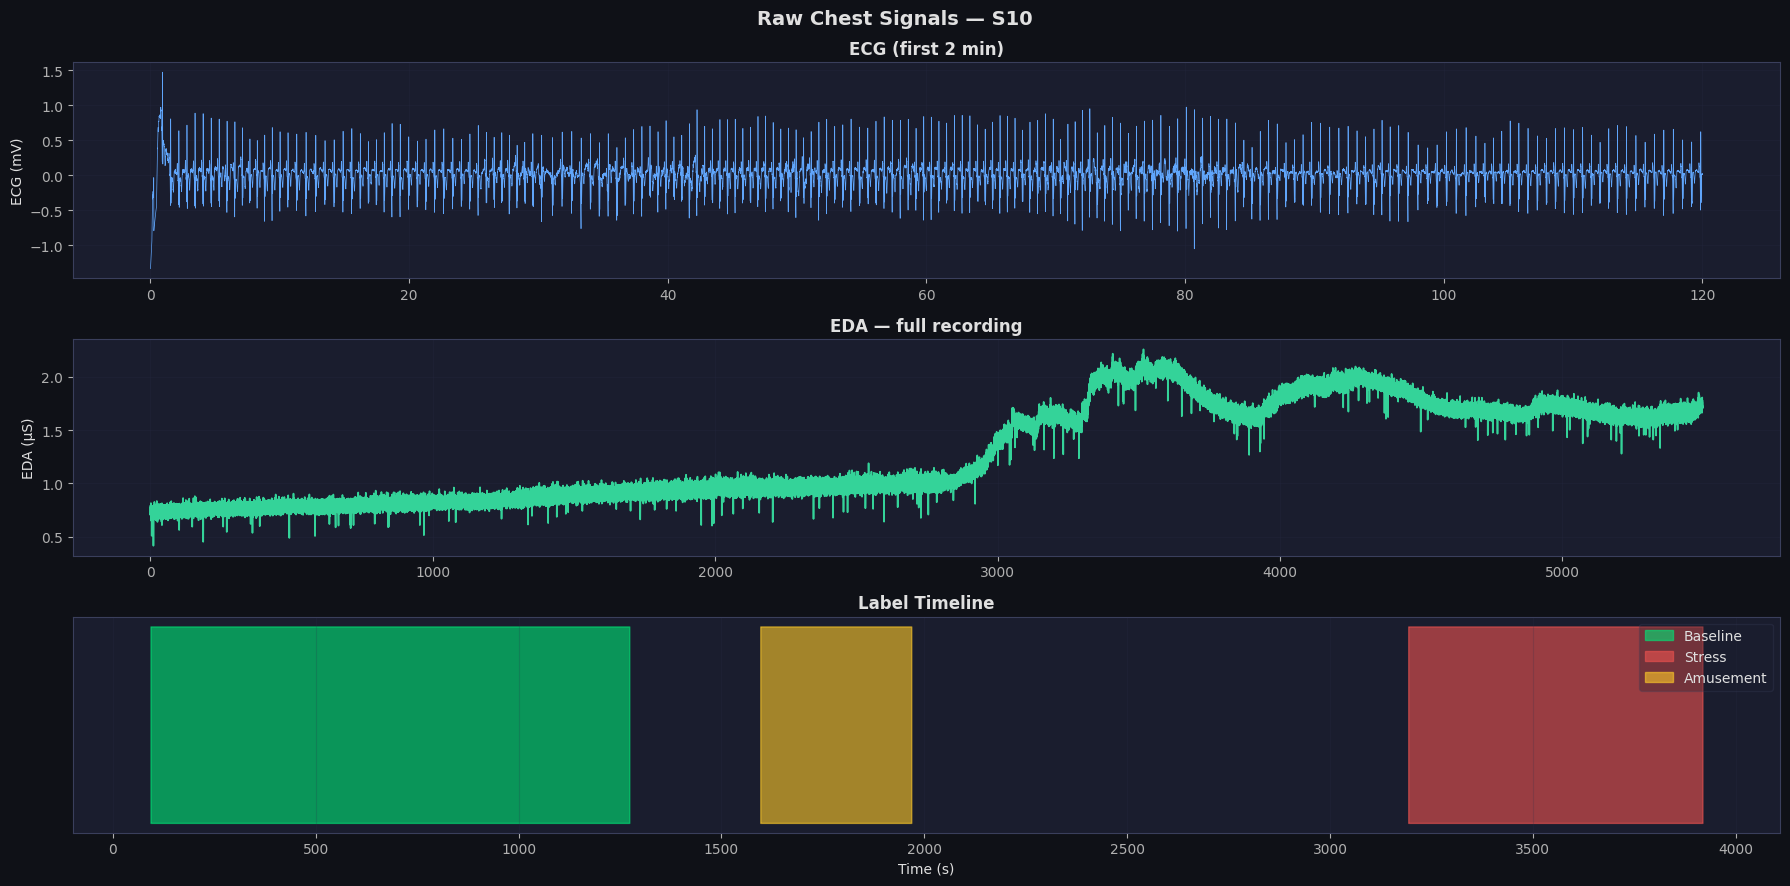

In [10]:
# ── CSV-based loader (replaces pkl loader) ────────────────────────────────────
CSV_PATH = '/kaggle/input/datasets/amineipad/wesad-small-dataset/wesad_100percent.csv'

FS_CHEST  = 700   # Hz — all chest signals in this CSV

WINDOW_SEC = 60
OVERLAP    = 0.5
MIN_PURITY = 0.80

WESAD_TO_APP = {1: 0, 2: 1, 3: 2}   # Baseline→Calm, Stress→Elevated, Amusement→Danger

print("⏳ Reading CSV (60M rows, may take ~30s)...")
df_raw = pd.read_csv(CSV_PATH)

# Compute ACC magnitude from XYZ
df_raw['ACC'] = np.linalg.norm(df_raw[['ACC_X','ACC_Y','ACC_Z']].values, axis=1)

print(f"   Shape: {df_raw.shape}")
print(f"   Labels: {sorted(df_raw['Label'].unique())}")
print(f"   Subjects: {sorted(df_raw['Subject'].unique())}")

# ── Segment function (same logic, works on numpy arrays) ─────────────────────
def segment(sig, lbl_sig, fs):
    win_len = int(WINDOW_SEC * fs)
    step    = int(win_len * (1 - OVERLAP))
    wins, lbls = [], []
    for start in range(0, len(sig) - win_len + 1, step):
        w   = sig[start:start + win_len]
        lbl = lbl_sig[start:start + win_len]
        valid = lbl[np.isin(lbl, [1, 2, 3])]
        if len(valid) == 0 or len(valid) / len(lbl) < MIN_PURITY:
            continue
        u, c  = np.unique(valid, return_counts=True)
        best  = u[c.argmax()]
        if c.max() / len(valid) >= MIN_PURITY:
            wins.append(w.astype(np.float32))
            lbls.append(int(best))
    return wins, lbls

# ── Load & window all subjects ────────────────────────────────────────────────
all_ecg, all_eda, all_temp, all_acc = [], [], [], []
all_wesad_labels, all_app_labels, all_sids = [], [], []

n_win_ecg = int(WINDOW_SEC * FS_CHEST)   # all signals are 700 Hz in this CSV

subjects = sorted(df_raw['Subject'].unique())
print(f"\n⏳ Windowing {len(subjects)} subjects...")
n_loaded = 0

for sid in subjects:
    sub = df_raw[df_raw['Subject'] == sid]

    ecg_sig  = sub['ECG'].values.astype(np.float32)
    eda_sig  = sub['EDA'].values.astype(np.float32)
    temp_sig = sub['TEMP'].values.astype(np.float32)
    acc_sig  = sub['ACC'].values.astype(np.float32)
    lbl_sig  = sub['Label'].values

    ecg_wins,  ecg_lbls  = segment(ecg_sig,  lbl_sig, FS_CHEST)
    eda_wins,  _         = segment(eda_sig,  lbl_sig, FS_CHEST)
    temp_wins, _         = segment(temp_sig, lbl_sig, FS_CHEST)
    acc_wins,  _         = segment(acc_sig,  lbl_sig, FS_CHEST)

    for i, (ew, el) in enumerate(zip(ecg_wins, ecg_lbls)):
        all_ecg.append(ew)
        all_wesad_labels.append(el)
        all_app_labels.append(WESAD_TO_APP[el])
        all_sids.append(sid)
        all_eda.append( eda_wins[i]  if i < len(eda_wins)  else np.zeros(n_win_ecg, np.float32))
        all_temp.append(temp_wins[i] if i < len(temp_wins) else np.zeros(n_win_ecg, np.float32))
        all_acc.append( acc_wins[i]  if i < len(acc_wins)  else np.zeros(n_win_ecg, np.float32))

    n_loaded += 1
    print(f"  ✅ {sid:4s} | {len(ecg_wins)} windows | "
          + str({k: int((np.array(ecg_lbls)==k).sum()) for k in [1,2,3]}))

all_wesad_labels = np.array(all_wesad_labels)
all_app_labels   = np.array(all_app_labels)
all_sids         = np.array(all_sids)

print(f"\n{'─'*50}")
print(f"Loaded {n_loaded} subjects  |  {len(all_ecg)} total windows")
print(f"\nApp stress-level distribution:")
for k, n in sorted(zip(*np.unique(all_app_labels, return_counts=True))):
    print(f"  {CLUSTER_ICONS[k]} {CLUSTER_LABELS[k]:35s}: {n} windows")

# ── Preview plot (ECG + EDA + label timeline for first subject) ───────────────
sid0 = subjects[0]
sub0 = df_raw[df_raw['Subject'] == sid0]

fig, axes = plt.subplots(3, 1, figsize=(18, 9), sharex=False)
fig.suptitle(f'Raw Chest Signals — {sid0}', fontsize=14, fontweight='bold')

ecg0  = sub0['ECG'].values
t_ecg = np.arange(min(FS_CHEST * 120, len(ecg0))) / FS_CHEST
axes[0].plot(t_ecg, ecg0[:len(t_ecg)], color='#60a5fa', lw=0.5)
axes[0].set_title('ECG (first 2 min)', fontweight='bold')
axes[0].set_ylabel('ECG (mV)'); axes[0].grid(True, alpha=0.2)

eda0  = sub0['EDA'].values
t_eda = np.arange(len(eda0)) / FS_CHEST
axes[1].plot(t_eda, eda0, color='#34d399', lw=1.2)
axes[1].set_title('EDA — full recording', fontweight='bold')
axes[1].set_ylabel('EDA (μS)'); axes[1].grid(True, alpha=0.2)

lbl0  = sub0['Label'].values
t_lbl = np.arange(len(lbl0)) / FS_CHEST
label_colors = {1:'#00e676', 2:'#ef5350', 3:'#ffca28'}
label_names  = {1:'Baseline', 2:'Stress', 3:'Amusement'}
for lv, col in label_colors.items():
    axes[2].fill_between(t_lbl, 0, 1, where=(lbl0==lv),
                          color=col, alpha=0.6, label=label_names[lv])
axes[2].set_title('Label Timeline', fontweight='bold')
axes[2].set_xlabel('Time (s)'); axes[2].set_yticks([])
axes[2].legend(loc='upper right', fontsize=10, framealpha=0.3)
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('raw_signals.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()

In [9]:
print("Labels:", df['Label'].unique())
print("Subjects:", df['Subject'].unique())
print("Rows per subject:")
print(df['Subject'].value_counts().sort_index())

Labels: [0 1 5 2 6 4 3 7]
Subjects: ['S14' 'S11' 'S13' 'S10' 'S8' 'S5' 'S7' 'S9' 'S15' 'S2' 'S6' 'S3' 'S4'
 'S16' 'S17']
Rows per subject:
Subject
S10    3847200
S11    3663100
S13    3875900
S14    3883600
S15    3676400
S16    3941700
S17    4144000
S2     4255300
S3     4545100
S4     4496100
S5     4380600
S6     4949700
S7     3666600
S8     3826200
S9     3656100
Name: count, dtype: int64


In [29]:
# ── Data Preparation : Feature matrix & NaN/Inf fix ──────────────────────────
X_hrv_cols = list(df_hrv.columns)
X_raw      = df_hrv[X_hrv_cols].values.copy()

print(f"   Raw feature matrix : {X_raw.shape}")
print(f"   Features           : {X_hrv_cols}")

df_prep = pd.DataFrame(X_raw, columns=X_hrv_cols)
df_prep.replace([np.inf, -np.inf], np.nan, inplace=True)

nan_before = df_prep.isna().sum().sum()
df_prep.fillna(df_prep.median(), inplace=True)
print(f"\n   NaN/Inf fixed      : {nan_before} values replaced with column median")

   Raw feature matrix : (1049, 35)
   Features           : ['HRV_MeanRR', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MeanHR', 'HRV_SDHR', 'HRV_HR_range', 'HRV_CVNN', 'HRV_RR_skew', 'HRV_RR_kurt', 'HRV_RR_ent', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'HRV_SI', 'HRV_LF', 'HRV_HF', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'EDA_mean', 'EDA_std', 'EDA_range', 'EDA_skew', 'EDA_slope', 'EDA_n_peaks', 'TEMP_mean', 'TEMP_std', 'TEMP_range', 'TEMP_slope', 'ACC_mean', 'ACC_std', 'ACC_dom_freq', 'ACC_psd_mean']

   NaN/Inf fixed      : 0 values replaced with column median


In [30]:
# ── Data Preparation : Outlier report ────────────────────────────────────────
print("   Per-feature outlier summary (values outside ±3 std):")
found = False
for col in X_hrv_cols:
    s   = df_prep[col]
    out = ((s - s.mean()).abs() > 3 * s.std()).sum()
    if out > 0:
        found = True
        print(f"     {col:25s}  outliers={out:4d}  "
              f"min={s.min():.2f}  max={s.max():.2f}")
if not found:
    print("     None found ✅")

   Per-feature outlier summary (values outside ±3 std):
     HRV_RMSSD                  outliers=   8  min=2.08  max=409.04
     HRV_RR_skew                outliers=   3  min=-5.00  max=3.53
     HRV_RR_kurt                outliers=  22  min=-1.92  max=34.85
     HRV_SD1                    outliers=   8  min=1.44  max=289.24
     HRV_SD1SD2                 outliers=   1  min=0.05  max=1.36
     HRV_SI                     outliers=  27  min=0.00  max=2.32
     HRV_LF                     outliers=  15  min=2.84  max=16074.29
     HRV_HF                     outliers=  18  min=1.38  max=29031.18
     HRV_LFHF                   outliers=  16  min=0.07  max=37.13
     EDA_mean                   outliers=  20  min=0.58  max=19.97
     EDA_std                    outliers=  10  min=0.01  max=1.77
     EDA_range                  outliers=   6  min=0.13  max=9.42
     EDA_skew                   outliers=   9  min=-6.51  max=4.17
     EDA_slope                  outliers=  14  min=-0.00  max=0.00
 

In [31]:
# ── Data Preparation : Robust scaling ────────────────────────────────────────
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(df_prep.values)
X_scaled = np.clip(X_scaled, -CLIP_RANGE, CLIP_RANGE)

print(f"   After RobustScaler + clip(±{CLIP_RANGE}):")
print(f"     min={X_scaled.min():.3f}  max={X_scaled.max():.3f}  "
      f"mean={X_scaled.mean():.3f}  std={X_scaled.std():.3f}")

X_hrv_s = X_scaled    # full scaled matrix — used later for cross_val_score

   After RobustScaler + clip(±5):
     min=-5.000  max=5.000  mean=0.167  std=1.038


In [32]:
# ── Data Preparation : Severity score ────────────────────────────────────────
sev_components = {}

def norm_clip(col):
    v = df_hrv[col].values.copy()
    v = np.clip(v, np.percentile(v, 1), np.percentile(v, 99))
    return (v - v.min()) / (v.max() - v.min() + 1e-9)

if 'HRV_SI'     in df_hrv.columns: sev_components['HRV_SI']       = norm_clip('HRV_SI')
if 'HRV_LFHF'  in df_hrv.columns: sev_components['HRV_LFHF']     = norm_clip('HRV_LFHF')
if 'HRV_MeanHR' in df_hrv.columns: sev_components['HRV_MeanHR']  = norm_clip('HRV_MeanHR')
if 'EDA_mean'   in df_hrv.columns: sev_components['EDA_mean']     = norm_clip('EDA_mean')
if 'HRV_SDNN'   in df_hrv.columns:
    sev_components['HRV_SDNN_inv'] = 1.0 - norm_clip('HRV_SDNN')   # low SDNN = high stress

weight_map = {
    'HRV_SI':       0.30,
    'HRV_LFHF':     0.25,
    'HRV_MeanHR':   0.20,
    'EDA_mean':     0.15,
    'HRV_SDNN_inv': 0.10,
}
total_w    = sum(weight_map[k] for k in sev_components)
sev_raw    = sum(weight_map[k] * sev_components[k] for k in sev_components) / total_w
y_severity = (sev_raw * 100).astype(np.float32)

print(f"   Severity score (0-100):")
print(f"     min={y_severity.min():.2f}  max={y_severity.max():.2f}  "
      f"mean={y_severity.mean():.2f}  std={y_severity.std():.2f}")
print(f"     Components used: {list(sev_components.keys())}")

   Severity score (0-100):
     min=4.76  max=76.63  mean=23.87  std=12.10
     Components used: ['HRV_SI', 'HRV_LFHF', 'HRV_MeanHR', 'EDA_mean', 'HRV_SDNN_inv']


In [33]:
# ── Data Preparation : Subject-aware train/test split ────────────────────────
np.random.seed(RANDOM_SEED)
unique_sids = np.unique(y_sids)
test_sids   = np.random.choice(unique_sids,
                                size=max(1, int(len(unique_sids) * TEST_SIZE)),
                                replace=False)
train_sids  = np.array([s for s in unique_sids if s not in test_sids])

train_idx = np.where(np.isin(y_sids, train_sids))[0]
test_idx  = np.where(np.isin(y_sids, test_sids))[0]

X_train = X_scaled[train_idx];          X_test      = X_scaled[test_idx]
y_train = y_app[train_idx];             y_test      = y_app[test_idx]
y_train_sev = y_severity[train_idx];    y_test_sev  = y_severity[test_idx]

print(f"   Train/test split (subject-aware, {int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)}):")
print(f"     Train subjects : {sorted(train_sids.tolist())}  ({len(train_idx)} windows)")
print(f"     Test  subjects : {sorted(test_sids.tolist())}   ({len(test_idx)} windows)")
print(f"\n   Class distribution:")
print(f"     {'Label':<25} {'Train':>8} {'Test':>8}")
for k in sorted(np.unique(y_app)):
    print(f"     {CLUSTER_LABELS[k][:25]:<25} "
          f"{(y_train==k).sum():>8} "
          f"{(y_test==k).sum():>8}")

   Train/test split (subject-aware, 80/20):
     Train subjects : ['S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S5', 'S7', 'S8', 'S9']  (840 windows)
     Test  subjects : ['S10', 'S4', 'S6']   (209 windows)

   Class distribution:
     Label                        Train     Test
     Calm — No stress signal        457      113
     Elevated — Monitor situat      250       63
     Danger signal — Acute str      133       33


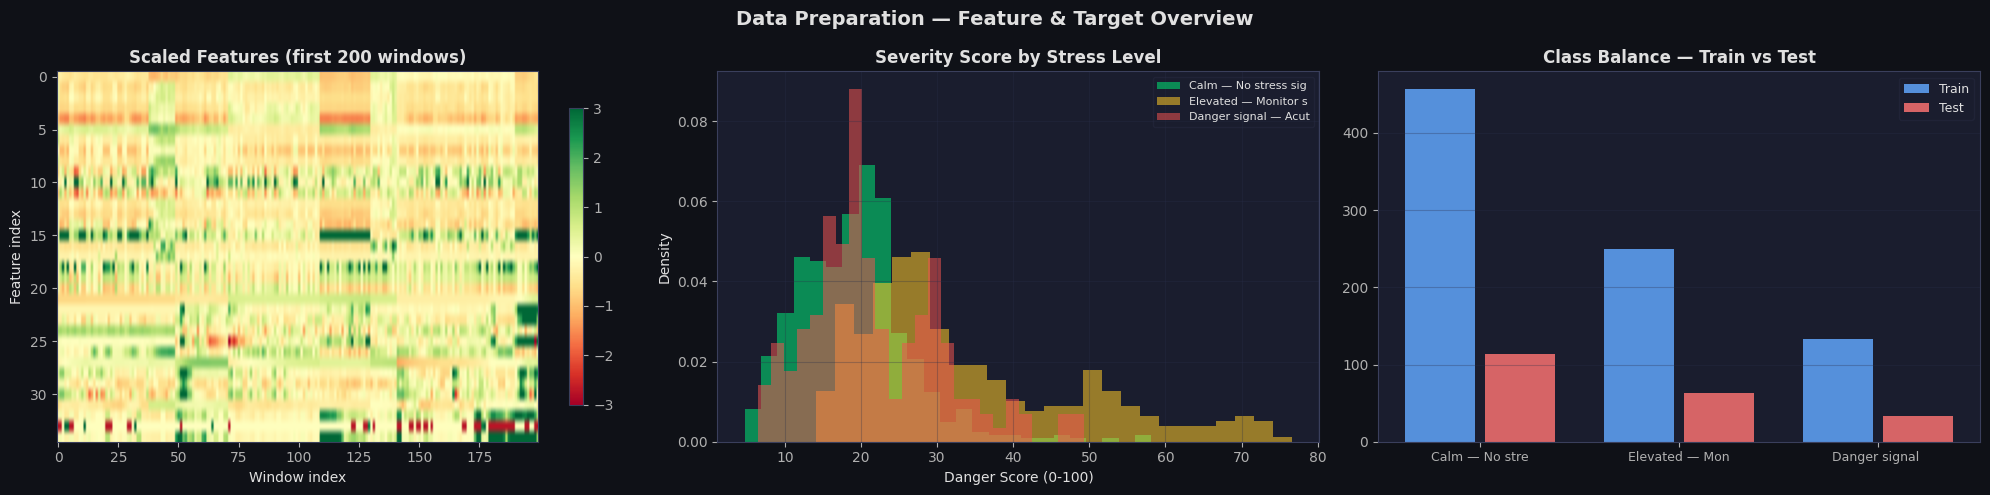


✅ Data preparation complete.
   X_train : (840, 35)   X_test : (209, 35)
   X_hrv_s : (1049, 35)  (full scaled, for CV)
   y_severity range : [4.8, 76.6]


In [34]:
# ── Data Preparation : Plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Data Preparation — Feature & Target Overview',
             fontsize=14, fontweight='bold')

# Scaled feature heatmap
sample_n = min(200, len(X_scaled))
im = axes[0].imshow(X_scaled[:sample_n].T, aspect='auto',
                     cmap='RdYlGn', vmin=-3, vmax=3)
axes[0].set_title(f'Scaled Features (first {sample_n} windows)', fontweight='bold')
axes[0].set_xlabel('Window index'); axes[0].set_ylabel('Feature index')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Severity score distribution by class
app_col3 = {0:'#00e676', 1:'#ffca28', 2:'#ef5350'}
for lbl, color in app_col3.items():
    mask = y_app == lbl
    axes[1].hist(y_severity[mask], bins=25, alpha=0.55, color=color,
                 label=CLUSTER_LABELS[lbl][:20], density=True)
axes[1].set_xlabel('Danger Score (0-100)'); axes[1].set_ylabel('Density')
axes[1].set_title('Severity Score by Stress Level', fontweight='bold')
axes[1].legend(fontsize=8, framealpha=0.2); axes[1].grid(True, alpha=0.3)

# Class balance bar
labels_bar   = [CLUSTER_LABELS[k][:14] for k in sorted(np.unique(y_app))]
train_counts = [(y_train == k).sum() for k in sorted(np.unique(y_app))]
test_counts  = [(y_test  == k).sum() for k in sorted(np.unique(y_app))]
x_bar = np.arange(len(labels_bar))
axes[2].bar(x_bar - 0.2, train_counts, 0.35, label='Train',
            color='#60a5fa', alpha=0.85)
axes[2].bar(x_bar + 0.2, test_counts,  0.35, label='Test',
            color='#f87171', alpha=0.85)
axes[2].set_xticks(x_bar)
axes[2].set_xticklabels(labels_bar, fontsize=9)
axes[2].set_title('Class Balance — Train vs Test', fontweight='bold')
axes[2].legend(fontsize=9, framealpha=0.2); axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('data_preparation.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()

print("\n✅ Data preparation complete.")
print(f"   X_train : {X_train.shape}   X_test : {X_test.shape}")
print(f"   X_hrv_s : {X_hrv_s.shape}  (full scaled, for CV)")
print(f"   y_severity range : [{y_severity.min():.1f}, {y_severity.max():.1f}]")

## 🔬 Module M2 — HRV + EDA + TEMP Feature Extraction

⏳ Extracting features from all windows...


  0%|          | 0/1049 [00:00<?, ?it/s]


✅ Extraction complete: 1049 windows · 35 features
   Features: ['HRV_MeanRR', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MeanHR', 'HRV_SDHR', 'HRV_HR_range', 'HRV_CVNN', 'HRV_RR_skew', 'HRV_RR_kurt', 'HRV_RR_ent', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'HRV_SI', 'HRV_LF', 'HRV_HF', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'EDA_mean', 'EDA_std', 'EDA_range', 'EDA_skew', 'EDA_slope', 'EDA_n_peaks', 'TEMP_mean', 'TEMP_std', 'TEMP_range', 'TEMP_slope', 'ACC_mean', 'ACC_std', 'ACC_dom_freq', 'ACC_psd_mean']

   Stress distribution (app labels):
     🟢 Calm — No stress signal            : 570
     🟡 Elevated — Monitor situation       : 313
     🔴 Danger signal — Acute stress       : 166


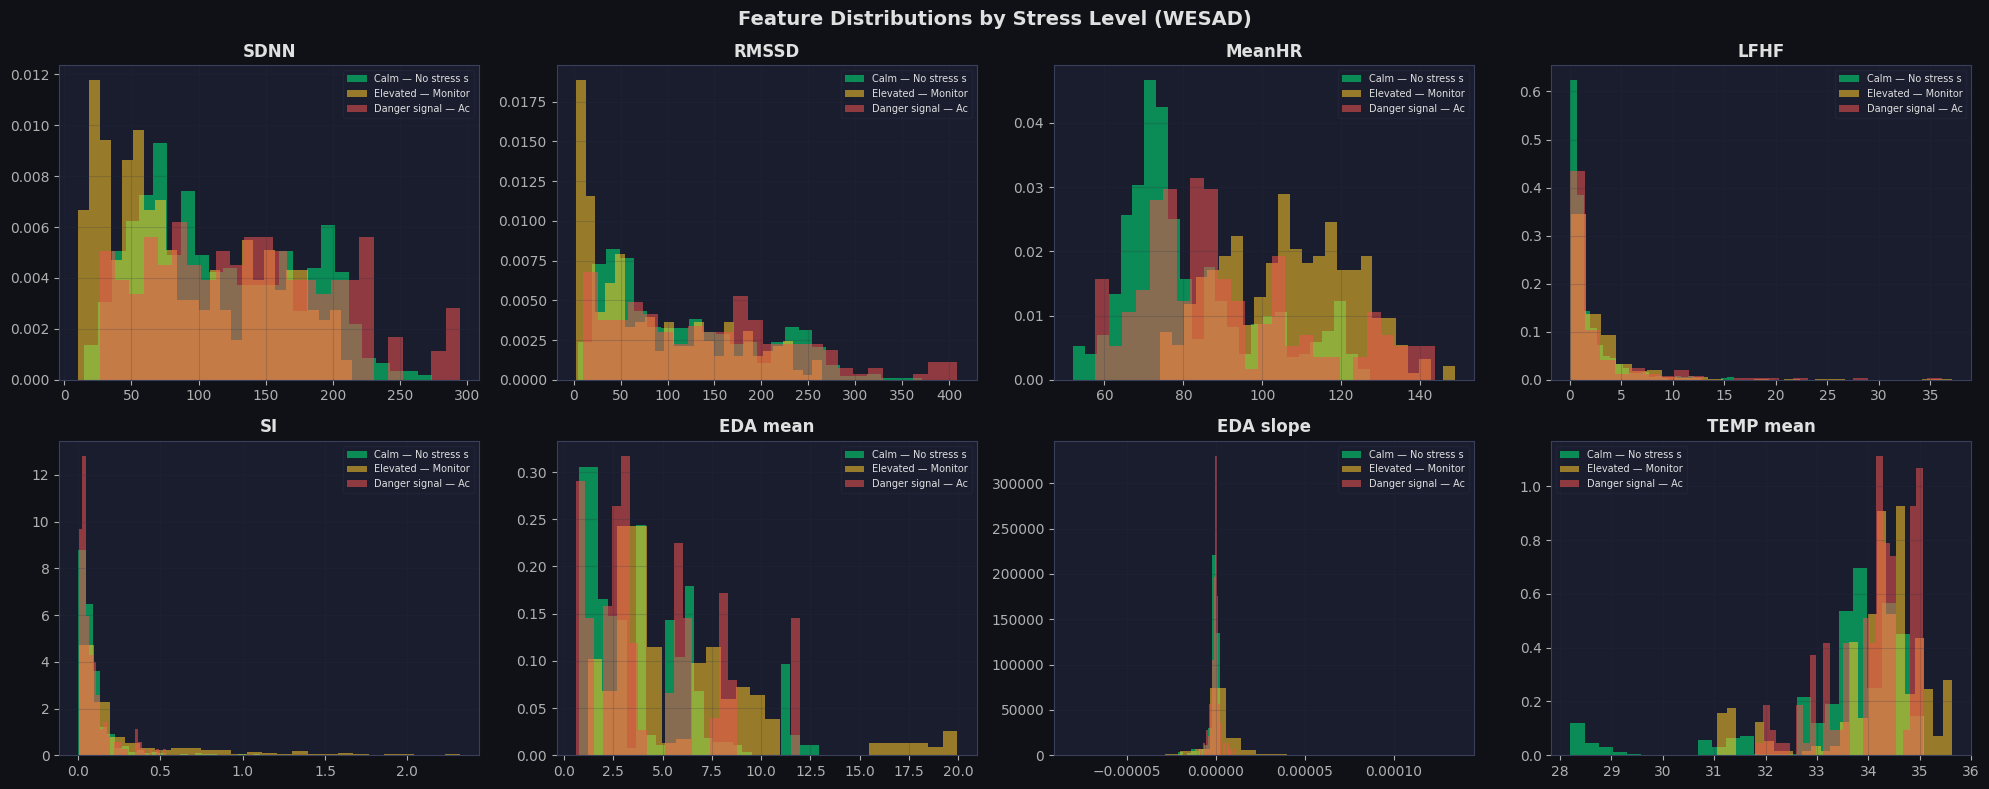

In [12]:
# ── Feature extraction (CSV / chest-signal version) ──────────────────────────
from scipy.signal import butter, filtfilt, find_peaks, welch
from scipy.stats import entropy as scipy_entropy

FS_ECG = 700   # all signals in this CSV are at 700 Hz

def bandpass(sig, lo, hi, fs, order=4):
    nyq  = 0.5 * fs
    b, a = butter(order, [lo/nyq, min(hi/nyq, 0.999)], btype='band')
    return filtfilt(b, a, sig)

def rr_from_ecg(ecg, fs=FS_ECG):
    """Detect R-peaks in ECG, return RR intervals in ms."""
    filt = bandpass(ecg, 0.5, 40.0, fs)
    min_dist     = int(fs * 0.35)               # ~170 bpm max
    height_thresh = np.percentile(filt, 75)
    peaks, _ = find_peaks(filt, distance=min_dist, height=height_thresh)
    if len(peaks) < 4:
        return None
    rr = np.diff(peaks) / fs * 1000.0
    rr = rr[(rr > 300) & (rr < 2000)]
    return rr if len(rr) >= 4 else None

def hrv_features(rr):
    f    = {}
    diff = np.diff(rr)
    f['HRV_MeanRR']   = float(np.mean(rr))
    f['HRV_SDNN']     = float(np.std(rr))
    f['HRV_RMSSD']    = float(np.sqrt(np.mean(diff**2)))
    f['HRV_pNN50']    = float(np.mean(np.abs(diff) > 50) * 100)
    f['HRV_pNN20']    = float(np.mean(np.abs(diff) > 20) * 100)
    f['HRV_MeanHR']   = float(np.mean(60000 / rr))
    f['HRV_SDHR']     = float(np.std(60000 / rr))
    f['HRV_HR_range'] = float(np.max(60000/rr) - np.min(60000/rr))
    f['HRV_CVNN']     = float(np.std(rr) / (np.mean(rr) + 1e-9))
    f['HRV_RR_skew']  = float(pd.Series(rr).skew())
    f['HRV_RR_kurt']  = float(pd.Series(rr).kurt())
    f['HRV_RR_ent']   = float(scipy_entropy(np.histogram(rr, bins=15)[0] + 1e-9))
    sd1 = float(np.std(diff) / np.sqrt(2))
    sd2 = float(np.sqrt(max(2*np.std(rr)**2 - 0.5*np.std(diff)**2, 0)))
    f['HRV_SD1']    = sd1
    f['HRV_SD2']    = sd2
    f['HRV_SD1SD2'] = float(sd1 / (sd2 + 1e-9))
    # Baevsky stress index
    try:
        mo  = float(pd.Series(rr).mode()[0])
        amo = float(np.sum(np.abs(rr - mo) < 50) / len(rr) * 100)
        mxd = float(np.max(rr) - np.min(rr))
        f['HRV_SI'] = float(amo / (2 * mo * mxd / 1000 + 1e-9))
    except Exception:
        f['HRV_SI'] = 0.0
    # Frequency domain (Welch on interpolated RR)
    try:
        t_rr = np.cumsum(rr) / 1000.0
        t_u  = np.arange(t_rr[0], t_rr[-1], 0.25)
        rr_i = np.interp(t_u, t_rr, rr)
        freqs, psd = welch(rr_i, fs=4.0, nperseg=min(128, len(rr_i)))
        lf = (freqs >= 0.04) & (freqs < 0.15)
        hf = (freqs >= 0.15) & (freqs < 0.40)
        lf_p = float(np.trapz(psd[lf], freqs[lf])) if lf.sum() > 0 else 0.0
        hf_p = float(np.trapz(psd[hf], freqs[hf])) if hf.sum() > 0 else 0.0
        f['HRV_LF']   = lf_p
        f['HRV_HF']   = hf_p
        f['HRV_LFHF'] = float(lf_p / (hf_p + 1e-9))
        f['HRV_LFn']  = float(lf_p / (lf_p + hf_p + 1e-9))
        f['HRV_HFn']  = float(hf_p / (lf_p + hf_p + 1e-9))
    except Exception:
        for k in ['HRV_LF','HRV_HF','HRV_LFHF','HRV_LFn','HRV_HFn']:
            f[k] = 0.0
    return f

def eda_features(eda):
    f = {}
    f['EDA_mean']    = float(np.mean(eda))
    f['EDA_std']     = float(np.std(eda))
    f['EDA_range']   = float(np.max(eda) - np.min(eda))
    f['EDA_skew']    = float(pd.Series(eda).skew())
    f['EDA_slope']   = float(np.polyfit(np.arange(len(eda)), eda, 1)[0]) if len(eda) > 1 else 0.0
    peaks, _ = find_peaks(eda, height=np.mean(eda), distance=2) if len(eda) > 4 else ([], None)
    f['EDA_n_peaks'] = float(len(peaks))
    return f

def temp_features(tmp):
    f = {}
    f['TEMP_mean']  = float(np.mean(tmp))
    f['TEMP_std']   = float(np.std(tmp))
    f['TEMP_range'] = float(np.max(tmp) - np.min(tmp))
    f['TEMP_slope'] = float(np.polyfit(np.arange(len(tmp)), tmp, 1)[0]) if len(tmp) > 1 else 0.0
    return f

def acc_features(acc, fs=FS_ECG):
    f = {}
    f['ACC_mean'] = float(np.mean(acc))
    f['ACC_std']  = float(np.std(acc))
    if len(acc) > 8:
        freqs, psd = welch(acc, fs=fs, nperseg=min(256, len(acc)))
        f['ACC_dom_freq'] = float(freqs[np.argmax(psd)])
        f['ACC_psd_mean'] = float(np.mean(psd))
    else:
        f['ACC_dom_freq'] = f['ACC_psd_mean'] = 0.0
    return f

# ── Extract features from every window ───────────────────────────────────────
print("⏳ Extracting features from all windows...")
rows, valid_idx = [], []

for i in tqdm(range(len(all_ecg))):
    rr = rr_from_ecg(all_ecg[i], FS_ECG)
    if rr is None:
        continue
    row = {}
    row.update(hrv_features(rr))
    row.update(eda_features(all_eda[i]))
    row.update(temp_features(all_temp[i]))
    row.update(acc_features(all_acc[i], fs=FS_ECG))
    rows.append(row)
    valid_idx.append(i)

valid_idx = np.array(valid_idx, dtype=int)

if len(valid_idx) == 0:
    print("❌ No valid windows after feature extraction.")
    print(f"   all_ecg length  : {len(all_ecg)}")
    if len(all_ecg) > 0:
        rr_test = rr_from_ecg(all_ecg[0], FS_ECG)
        print(f"   Test RR window 0: {rr_test}")
        print(f"   ECG window 0 stats — min:{all_ecg[0].min():.3f}  "
              f"max:{all_ecg[0].max():.3f}  mean:{all_ecg[0].mean():.3f}")
else:
    df_hrv  = pd.DataFrame(rows)
    y_app   = all_app_labels[valid_idx]
    y_wesad = all_wesad_labels[valid_idx]
    y_sids  = all_sids[valid_idx]

    df_hrv.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_hrv.fillna(df_hrv.median(), inplace=True)

    print(f"\n✅ Extraction complete: {len(df_hrv)} windows · {df_hrv.shape[1]} features")
    print(f"   Features: {list(df_hrv.columns)}")
    print(f"\n   Stress distribution (app labels):")
    for k, n in zip(*np.unique(y_app, return_counts=True)):
        print(f"     {CLUSTER_ICONS[k]} {CLUSTER_LABELS[k]:35s}: {n}")

    # ── Quick distribution plots ──────────────────────────────────────────────
    key_feats = [c for c in ['HRV_SDNN','HRV_RMSSD','HRV_MeanHR','HRV_LFHF',
                              'HRV_SI','EDA_mean','EDA_slope','TEMP_mean']
                 if c in df_hrv.columns]
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    fig.suptitle('Feature Distributions by Stress Level (WESAD)',
                 fontsize=14, fontweight='bold')
    app_colors_3 = {0:'#00e676', 1:'#ffca28', 2:'#ef5350'}
    for ax, feat in zip(axes.flatten(), key_feats):
        for lbl, color in app_colors_3.items():
            vals = df_hrv.loc[y_app == lbl, feat].dropna()
            ax.hist(vals, bins=25, alpha=0.55, color=color, density=True,
                    label=CLUSTER_LABELS[lbl][:18])
        ax.set_title(feat.replace('HRV_','').replace('_',' '), fontweight='bold')
        ax.legend(fontsize=7, framealpha=0.2)
        ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=150,
                bbox_inches='tight', facecolor=DARK)
    plt.show()

## ⚙️ Module M3 — Feature Engineering & Composite Scores

✅ Feature engineering complete:
   HRV + EDA + TEMP + ACC features: 47
   Train: 839  Test: 210
   Composite scores: ANS_dysregulation_index, hrv_collapse_score, ...


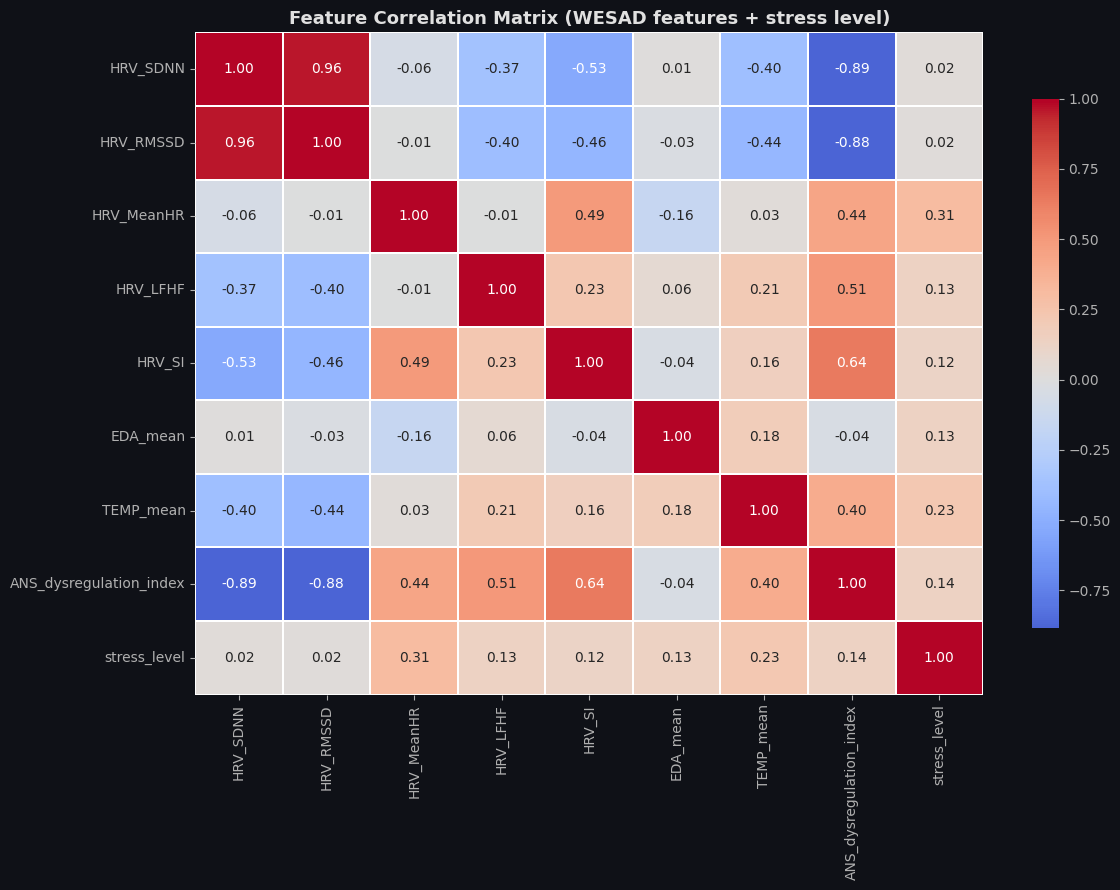

In [13]:
df = df_hrv.copy()

def safe_norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

if 'HRV_SDNN' in df.columns and 'HRV_RMSSD' in df.columns:
    df['hrv_collapse_score']    = 1 - (0.5*safe_norm(df['HRV_SDNN']) + 0.5*safe_norm(df['HRV_RMSSD']))

if 'HRV_LFHF' in df.columns:
    df['sympathetic_dominance'] = safe_norm(df['HRV_LFHF'])

if 'HRV_MeanHR' in df.columns:
    df['tachycardia_index']     = safe_norm(df['HRV_MeanHR'])

if 'HRV_SD1' in df.columns:
    df['complexity_loss']       = 1 - safe_norm(df['HRV_SD1'])

score_cols = [c for c in ['hrv_collapse_score','sympathetic_dominance',
                           'tachycardia_index','complexity_loss'] if c in df.columns]
df['ANS_dysregulation_index'] = df[score_cols].mean(axis=1)

for feat in ['HRV_SDNN','HRV_RMSSD','HRV_LF','HRV_HF','HRV_SI']:
    if feat in df.columns:
        df[f'{feat}_log'] = np.log1p(np.abs(df[feat]))

if 'HRV_RMSSD' in df.columns and 'HRV_MeanHR' in df.columns:
    df['rmssd_x_hr'] = df['HRV_RMSSD'] * df['HRV_MeanHR']
if 'HRV_SDNN' in df.columns and 'HRV_LFHF' in df.columns:
    df['sdnn_x_lfhf'] = df['HRV_SDNN'] * df['HRV_LFHF']

X_hrv_cols = list(df.columns)
X_hrv      = df.values
scaler_hrv = RobustScaler()
X_hrv_s    = scaler_hrv.fit_transform(X_hrv)

# Train/test split (stratified on 3-class app labels)
X_train, X_test, y_train, y_test = train_test_split(
    X_hrv_s, y_app, test_size=0.2, stratify=y_app, random_state=42
)

# Stress severity score for regression (0-100, derived from physiology)
def make_severity_score(y_3class, df_feat):
    base = np.array([15.0, 50.0, 85.0])[y_3class]
    if 'HRV_SI' in df_feat.columns:
        si = safe_norm(df_feat['HRV_SI'].values)
        base += (si - 0.5) * 20
    if 'EDA_mean' in df_feat.columns:
        eda = safe_norm(df_feat['EDA_mean'].values)
        base += (eda - 0.5) * 10
    return np.clip(base + np.random.normal(0, 3, len(base)), 0, 100).astype(np.float32)

y_severity = make_severity_score(y_app, df)
_, _, y_train_sev, y_test_sev = train_test_split(
    X_hrv_s, y_severity, test_size=0.2, random_state=42
)

print(f"✅ Feature engineering complete:")
print(f"   HRV + EDA + TEMP + ACC features: {X_hrv_s.shape[1]}")
print(f"   Train: {len(X_train)}  Test: {len(X_test)}")
print(f"   Composite scores: ANS_dysregulation_index, hrv_collapse_score, ...")

# Correlation heatmap
key_feats = [c for c in ['HRV_SDNN','HRV_RMSSD','HRV_MeanHR','HRV_LFHF',
                           'HRV_SI','EDA_mean','TEMP_mean','ANS_dysregulation_index'] if c in df.columns]
df_corr = df[key_feats].copy()
df_corr['stress_level'] = y_app
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.3, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Matrix (WESAD features + stress level)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()


## 🔵 Module M4 — Unsupervised Clustering
KMeans · DBSCAN · Agglomerative + t-SNE + Dendrogram.
Runs **without labels** to discover natural groupings, then compares to true WESAD stress labels.


🔍 KMeans sweep (k=2..6):
   k=2  Silhouette=0.9967  Inertia=138872
   k=3  Silhouette=0.9005  Inertia=100512
   k=4  Silhouette=0.3750  Inertia=88481
   k=5  Silhouette=0.3856  Inertia=79977
   k=6  Silhouette=0.3570  Inertia=73631


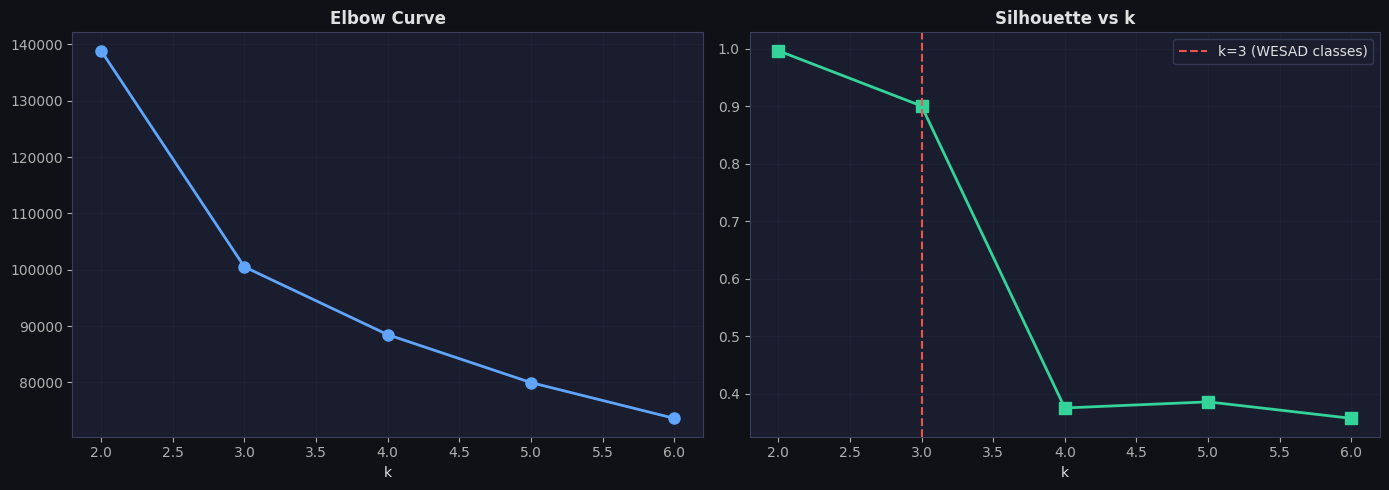


KMeans (k=3): Silhouette=0.9005  ARI vs stress labels=-0.0004
DBSCAN: 0 cluster found — try adjusting eps
Agglomerative (k=3, ward): Sil=0.9095  ARI=-0.0012

📊 Clustering Comparison:
       Method  Silhouette       ARI
 KMeans (k=3)    0.900487 -0.000443
       DBSCAN    0.000000  0.000000
Agglomerative    0.909492 -0.001153


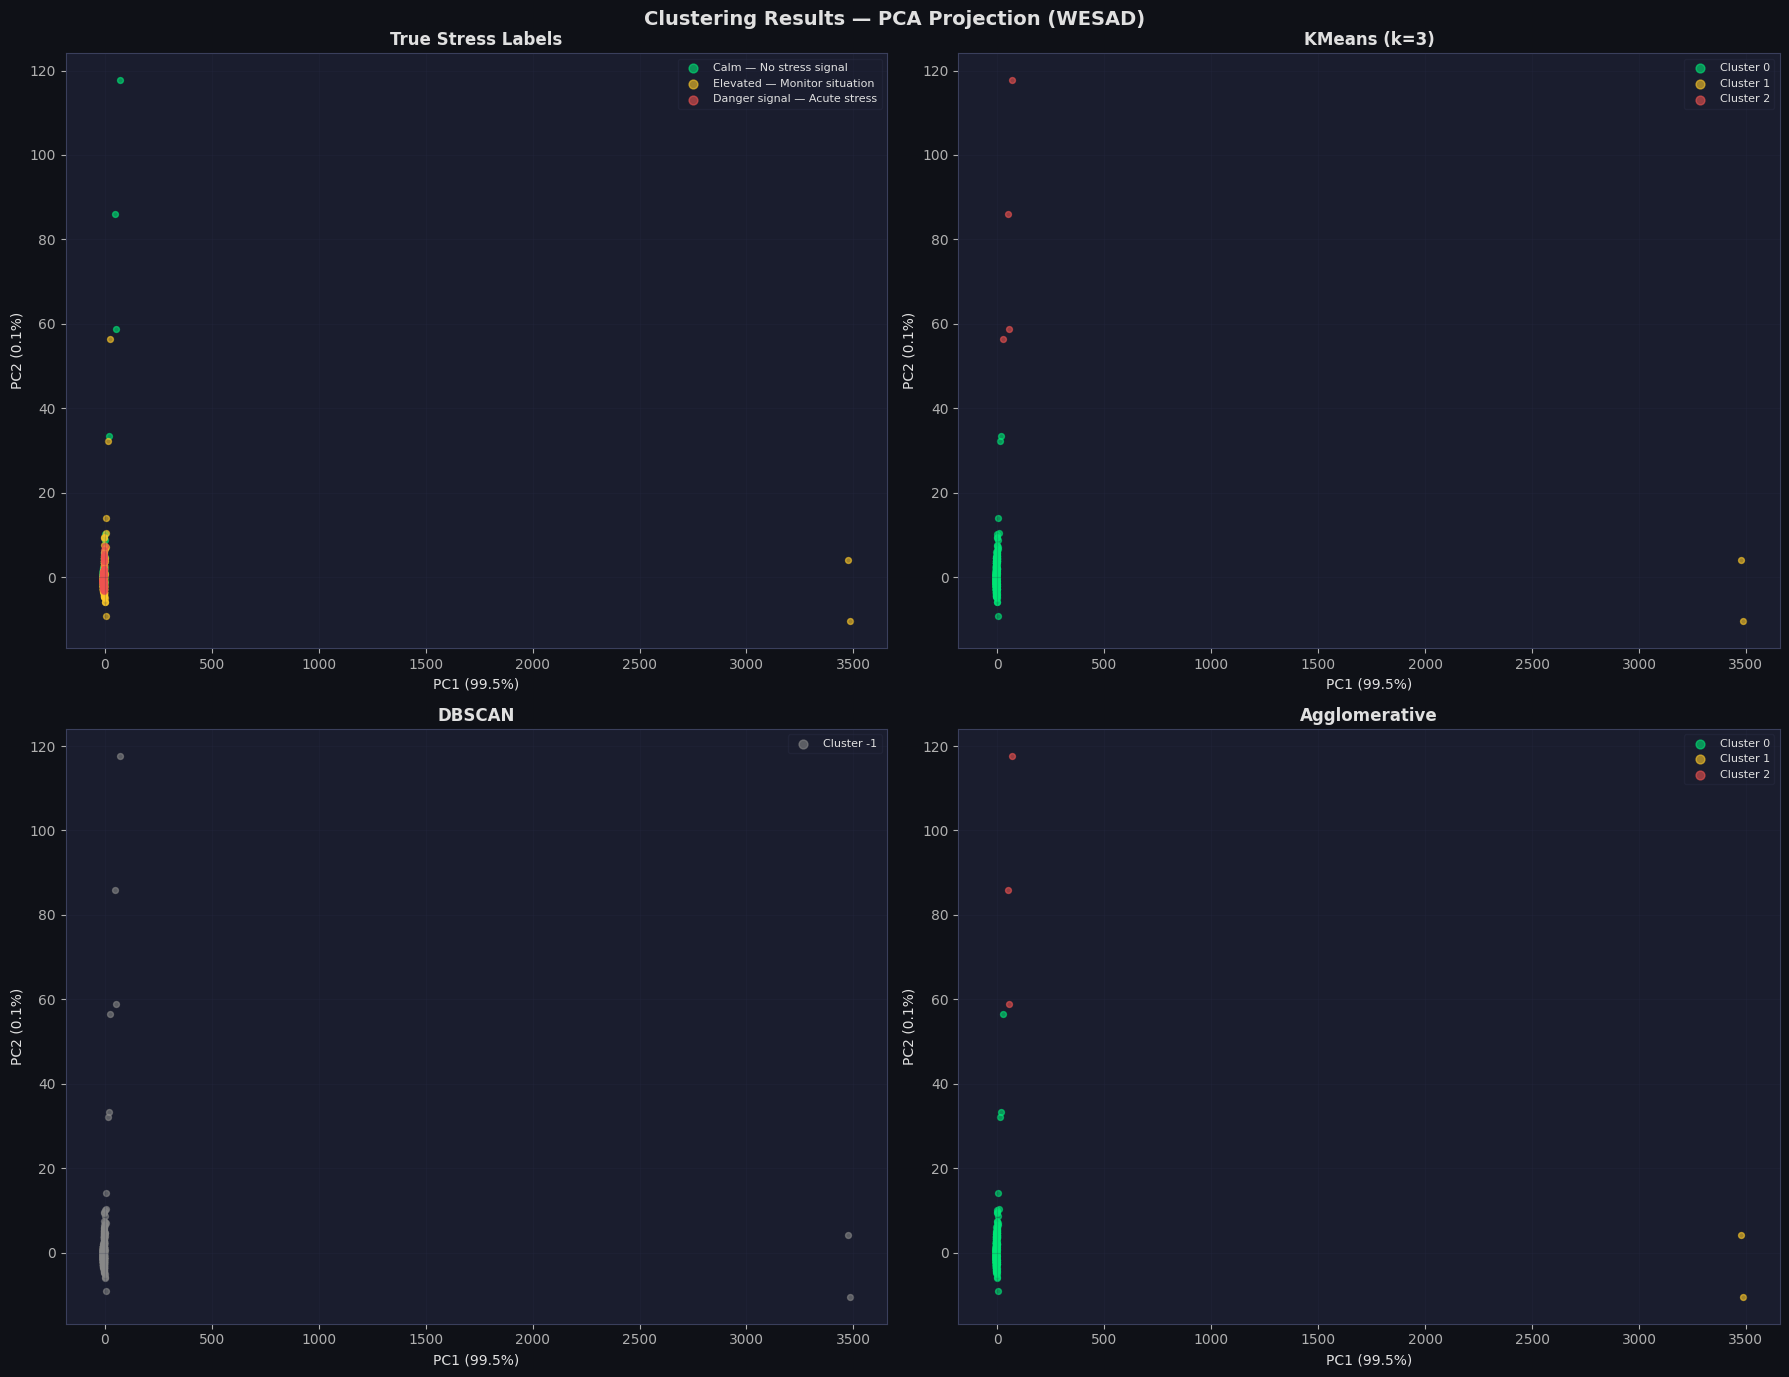

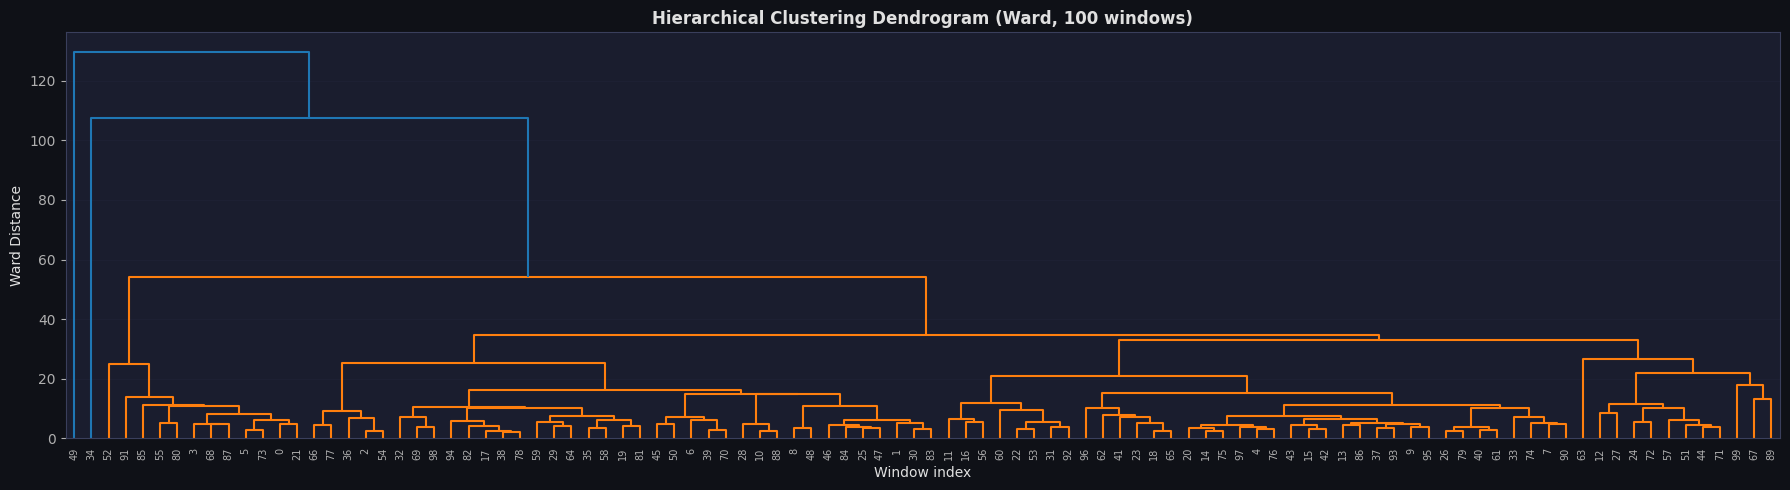

⏳ Computing t-SNE...


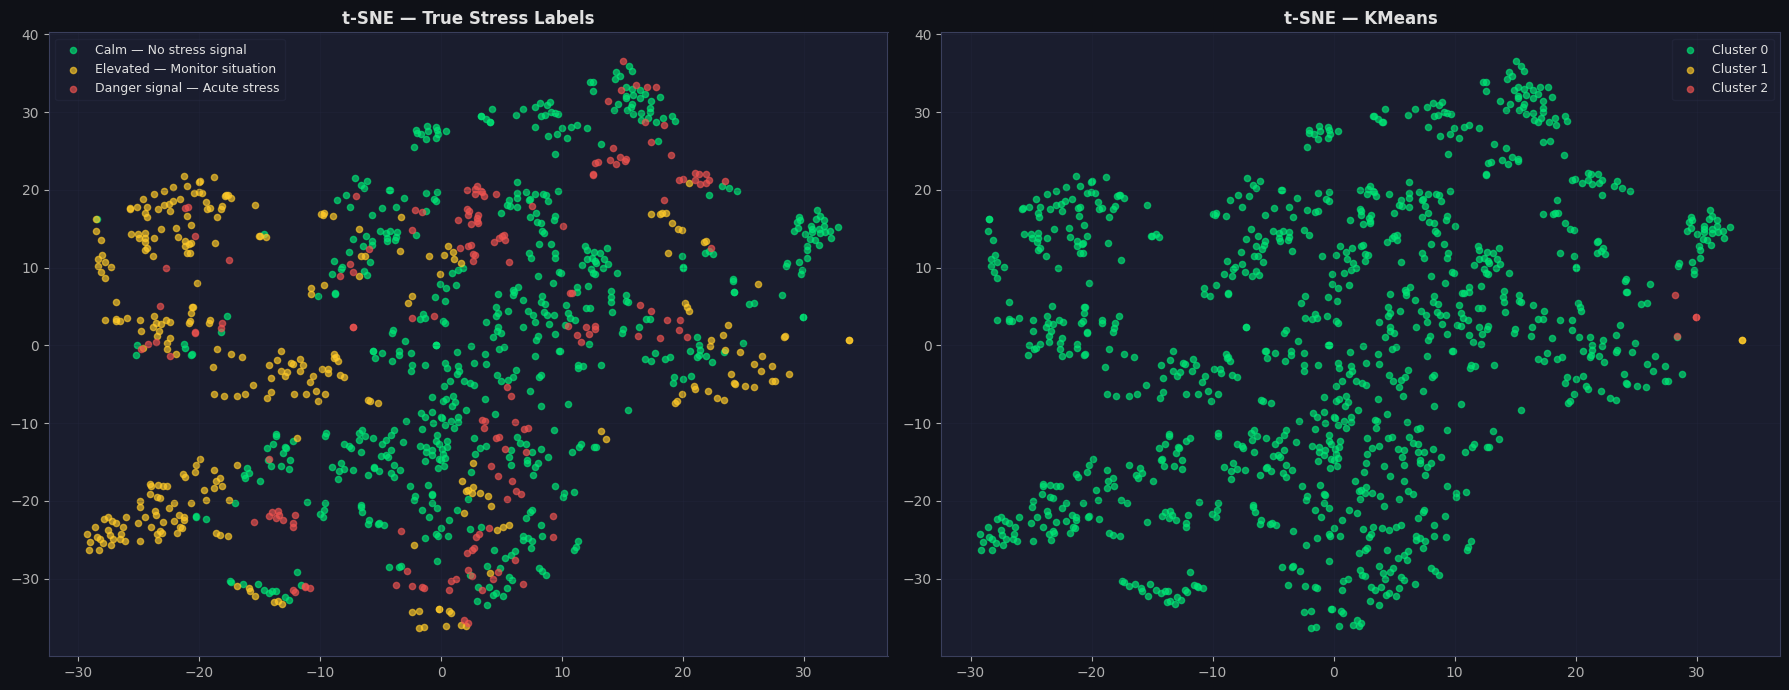

In [14]:
# ── PCA for visualization ─────────────────────────────────────────────────────
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_hrv_s)

# ── KMeans sweep k=2..6 ───────────────────────────────────────────────────────
print("🔍 KMeans sweep (k=2..6):")
k_range, sil_scores, inertias = range(2,7), [], []
for k in k_range:
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_hrv_s)
    sil  = silhouette_score(X_hrv_s, labs)
    sil_scores.append(sil); inertias.append(km.inertia_)
    print(f"   k={k}  Silhouette={sil:.4f}  Inertia={km.inertia_:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, 'o-', color='#60a5fa', lw=2, ms=8)
axes[0].set_title('Elbow Curve', fontweight='bold'); axes[0].set_xlabel('k'); axes[0].grid(True, alpha=0.3)
axes[1].plot(list(k_range), sil_scores, 's-', color='#34d399', lw=2, ms=8)
axes[1].axvline(3, color='#ef5350', lw=1.5, linestyle='--', label='k=3 (WESAD classes)')
axes[1].set_title('Silhouette vs k', fontweight='bold'); axes[1].set_xlabel('k')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_sweep.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()

# ── KMeans k=3 ────────────────────────────────────────────────────────────────
km3 = KMeans(n_clusters=3, random_state=42, n_init=15)
km3_labels = km3.fit_predict(X_hrv_s)
km_sil = silhouette_score(X_hrv_s, km3_labels)
km_ari = adjusted_rand_score(y_app, km3_labels)
print(f"\nKMeans (k=3): Silhouette={km_sil:.4f}  ARI vs stress labels={km_ari:.4f}")

# ── DBSCAN ────────────────────────────────────────────────────────────────────
db = DBSCAN(eps=1.2, min_samples=5)
db_labels = db.fit_predict(X_hrv_s)
n_cl  = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noi = int((db_labels==-1).sum())
if n_cl > 1:
    vm = db_labels != -1
    db_sil = silhouette_score(X_hrv_s[vm], db_labels[vm])
    db_ari = adjusted_rand_score(y_app[vm], db_labels[vm])
    print(f"DBSCAN: {n_cl} clusters, {n_noi} noise  Sil={db_sil:.4f}  ARI={db_ari:.4f}")
else:
    db_sil = db_ari = 0.0
    print(f"DBSCAN: {n_cl} cluster found — try adjusting eps")

# ── Agglomerative ─────────────────────────────────────────────────────────────
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_hrv_s)
agg_sil = silhouette_score(X_hrv_s, agg_labels)
agg_ari = adjusted_rand_score(y_app, agg_labels)
print(f"Agglomerative (k=3, ward): Sil={agg_sil:.4f}  ARI={agg_ari:.4f}")

# ── Cluster comparison summary ─────────────────────────────────────────────────
print("\n📊 Clustering Comparison:")
print(pd.DataFrame({
    'Method':    ['KMeans (k=3)','DBSCAN','Agglomerative'],
    'Silhouette':[km_sil, db_sil, agg_sil],
    'ARI':       [km_ari, db_ari, agg_ari],
}).to_string(index=False))

# ── Scatter 2×2 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Clustering Results — PCA Projection (WESAD)', fontsize=14, fontweight='bold')
app_col = {0:'#00e676', 1:'#ffca28', 2:'#ef5350'}
for ax, (labs, title) in zip(axes.flatten(), [
    (y_app,      'True Stress Labels'),
    (km3_labels, 'KMeans (k=3)'),
    (db_labels,  'DBSCAN'),
    (agg_labels, 'Agglomerative'),
]):
    for lbl in np.unique(labs):
        mask  = labs == lbl
        color = app_col.get(lbl, '#888888')
        label = CLUSTER_LABELS.get(lbl, f'Cluster {lbl}') if title == 'True Stress Labels' else f'Cluster {lbl}'
        ax.scatter(X_pca[mask,0], X_pca[mask,1], c=[color], alpha=0.6, s=18, label=label)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(fontsize=8, framealpha=0.2, markerscale=1.5); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('clustering_results.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()

# ── Dendrogram (sample) ───────────────────────────────────────────────────────
idx_s = np.random.choice(len(X_hrv_s), min(100, len(X_hrv_s)), replace=False)
Z = linkage(X_hrv_s[idx_s], method='ward')
fig, ax = plt.subplots(figsize=(18, 5))
dendrogram(Z, ax=ax, leaf_rotation=90, leaf_font_size=7, color_threshold=0.7*max(Z[:,2]))
ax.set_title('Hierarchical Clustering Dendrogram (Ward, 100 windows)', fontweight='bold')
ax.set_xlabel('Window index'); ax.set_ylabel('Ward Distance')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()

# ── t-SNE ─────────────────────────────────────────────────────────────────────
print("⏳ Computing t-SNE...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_hrv_s)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (labs, title) in [(axes[0], (y_app,'t-SNE — True Stress Labels')),
                            (axes[1], (km3_labels,'t-SNE — KMeans'))]:
    for lbl in np.unique(labs):
        mask  = labs == lbl
        color = app_col.get(lbl, '#888888')
        ax.scatter(X_tsne[mask,0], X_tsne[mask,1], c=[color], alpha=0.65, s=20,
                   label=CLUSTER_LABELS.get(lbl, f'Cluster {lbl}') if 'True' in title else f'Cluster {lbl}')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.2); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('tsne.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()


## 🤖 Module M5 — Supervised Classification (RF + XGBoost + SVM Stacking)

📊 5-Fold Cross-Validation (Macro F1):
  Random Forest              F1=0.8944 ± 0.0155


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:25:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:25:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:25:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:25:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

  XGBoost/GB                 F1=0.9549 ± 0.0155
  SVM                        F1=0.6851 ± 0.0343


[09:25:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:25:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:25:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:25:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:25:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:25:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:25:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:25:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:25:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" 

  Stacking Ensemble          F1=0.7499 ± 0.0989

⏳ Training stacking ensemble...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:26:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[09:26:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:26:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:26:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:26:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:26:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




📊 Test Set Report (3 stress levels):
                              precision    recall  f1-score   support

     Calm — No stress signal       0.98      0.98      0.98       114
Elevated — Monitor situation       0.91      0.98      0.95        63
Danger signal — Acute stress       1.00      0.85      0.92        33

                    accuracy                           0.96       210
                   macro avg       0.96      0.94      0.95       210
                weighted avg       0.96      0.96      0.96       210

  Macro F1 (test): 0.9490


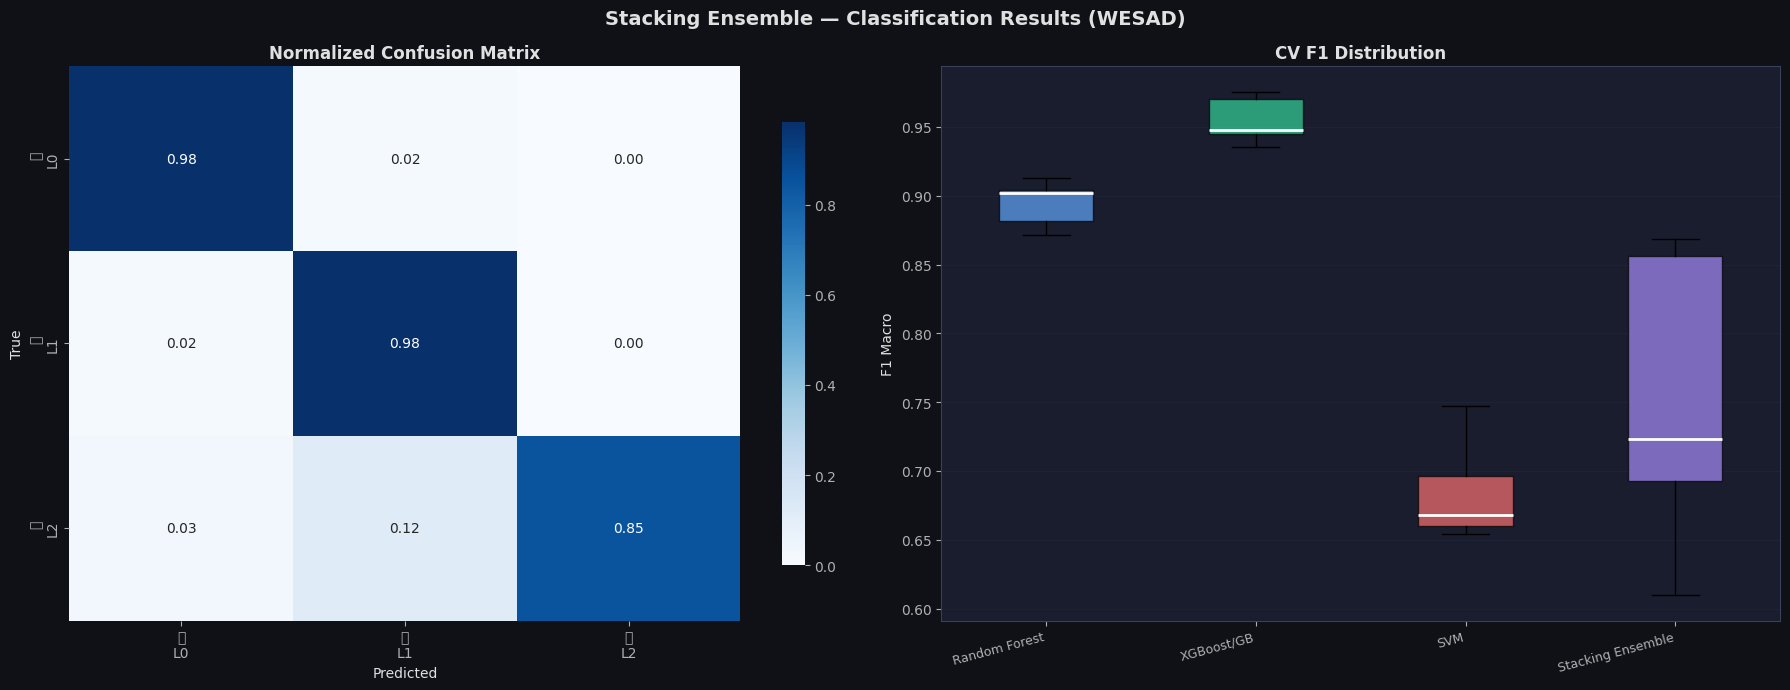

In [16]:
rf_clf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
svm_clf = SVC(C=10, kernel='rbf', gamma='scale', probability=True,
               class_weight='balanced', random_state=42)
if HAS_XGB:
    xgb_clf = XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', use_label_encoder=False,
        random_state=42, n_jobs=-1
    )
else:
    xgb_clf = GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42
    )

meta_lr      = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
stacking_clf = StackingClassifier(
    estimators=[('rf', rf_clf), ('xgb', xgb_clf), ('svm', svm_clf)],
    final_estimator=meta_lr, cv=5, passthrough=False, n_jobs=-1
)

# ── 5-fold CV comparison ──────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_cv = {}
print("📊 5-Fold Cross-Validation (Macro F1):")
for name, clf in [('Random Forest', rf_clf), ('XGBoost/GB', xgb_clf),
                   ('SVM', svm_clf), ('Stacking Ensemble', stacking_clf)]:
    scores = cross_val_score(clf, X_hrv_s, y_app, cv=cv, scoring='f1_macro', n_jobs=-1)
    results_cv[name] = scores
    print(f"  {name:25s}  F1={scores.mean():.4f} ± {scores.std():.4f}")

# ── Train final stacking model ─────────────────────────────────────────────────
print("\n⏳ Training stacking ensemble...")
stacking_clf.fit(X_train, y_train)
y_pred  = stacking_clf.predict(X_test)
y_proba = stacking_clf.predict_proba(X_test)

# Map 3 classes for report (0=Calm, 1=Elevated, 2=Danger signal)
tgt_names = [CLUSTER_LABELS[i] for i in range(3)]
print("\n📊 Test Set Report (3 stress levels):")
print(classification_report(y_test, y_pred, target_names=tgt_names, zero_division=0))
print(f"  Macro F1 (test): {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Stacking Ensemble — Classification Results (WESAD)', fontsize=14, fontweight='bold')

labels_cm = [f'{CLUSTER_ICONS[i]}\nL{i}' for i in range(3)]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm,
            ax=axes[0], cbar_kws={'shrink':0.8})
axes[0].set_title('Normalized Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

bp = axes[1].boxplot([results_cv[n] for n in results_cv], patch_artist=True,
                     notch=False, medianprops=dict(color='white', linewidth=2))
for patch, col in zip(bp['boxes'], ['#60a5fa','#34d399','#f87171','#a78bfa']):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1].set_xticklabels(list(results_cv.keys()), rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('F1 Macro'); axes[1].set_title('CV F1 Distribution', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('classification_results.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()


## 📈 Module M6 — ROC, Precision-Recall & Learning Curves

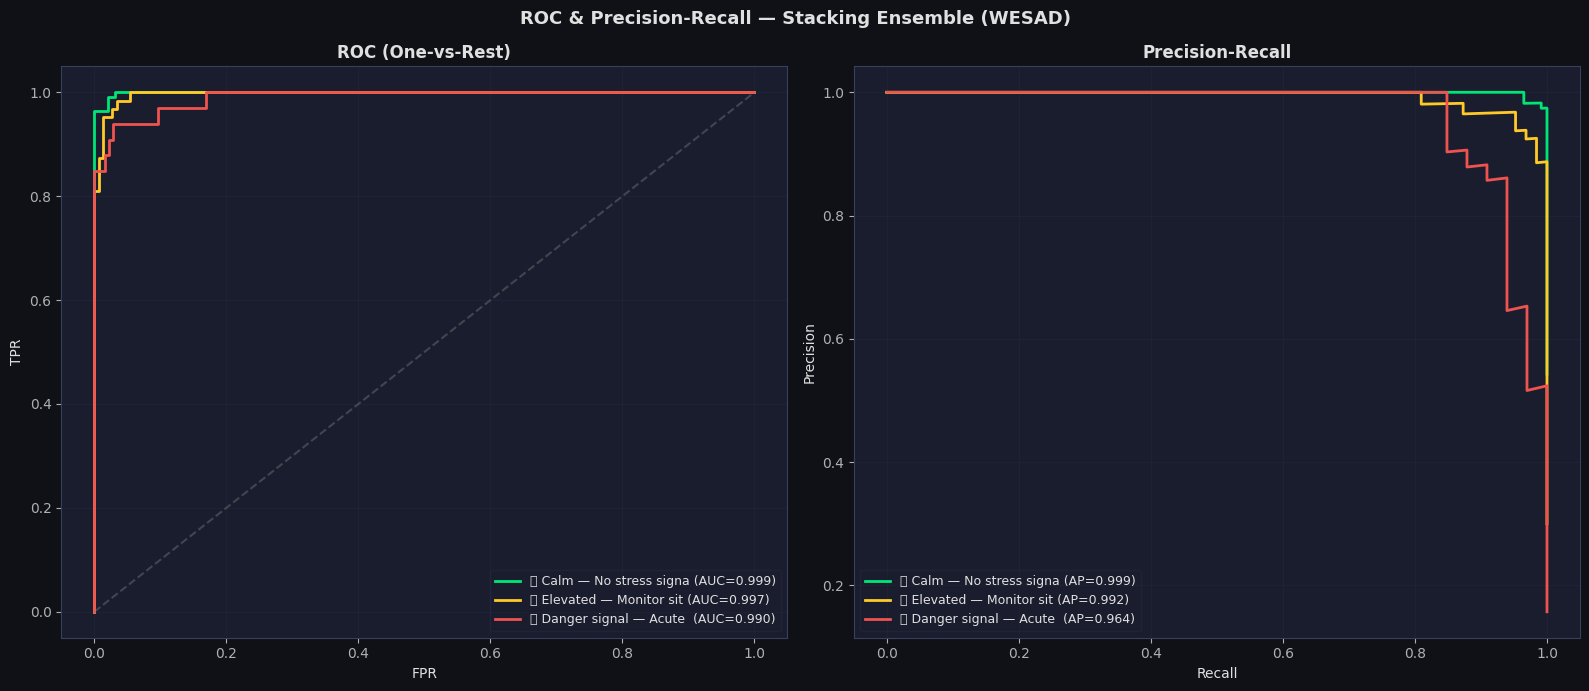

  Macro OvR AUC: 0.9952

⏳ Computing learning curves...


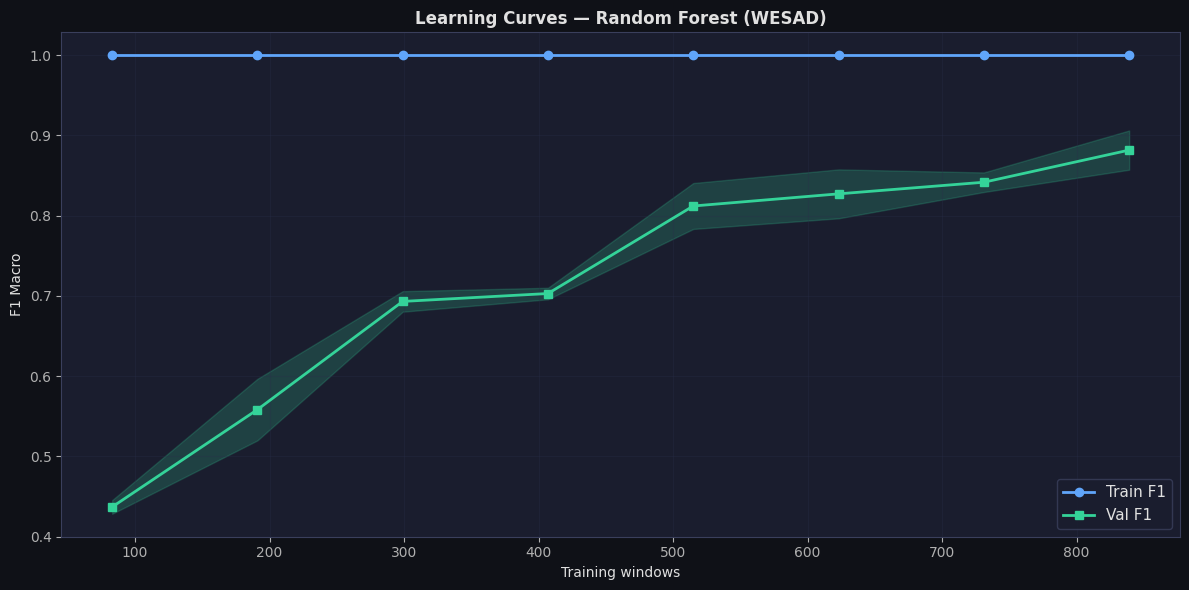

In [17]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_cls_eval = 3
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('ROC & Precision-Recall — Stacking Ensemble (WESAD)', fontsize=13, fontweight='bold')

for i in range(n_cls_eval):
    color = {0:'#00e676', 1:'#ffca28', 2:'#ef5350'}[i]
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{CLUSTER_ICONS[i]} {CLUSTER_LABELS[i][:22]} (AUC={auc(fpr,tpr):.3f})')
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f'{CLUSTER_ICONS[i]} {CLUSTER_LABELS[i][:22]} (AP={ap:.3f})')

axes[0].plot([0,1],[0,1],'--', color='gray', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC (One-vs-Rest)', fontweight='bold')
axes[0].legend(fontsize=9, framealpha=0.2); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall', fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.2); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f"  Macro OvR AUC: {roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro'):.4f}")

# ── Learning curves ───────────────────────────────────────────────────────────
print("\n⏳ Computing learning curves...")
rf_lc = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, tr_sc, val_sc = learning_curve(
    rf_lc, X_hrv_s, y_app, cv=cv_lc, scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train_sizes, tr_sc.mean(axis=1), 'o-', color='#60a5fa', lw=2, label='Train F1')
ax.fill_between(train_sizes, tr_sc.mean(axis=1)-tr_sc.std(axis=1),
                tr_sc.mean(axis=1)+tr_sc.std(axis=1), alpha=0.2, color='#60a5fa')
ax.plot(train_sizes, val_sc.mean(axis=1), 's-', color='#34d399', lw=2, label='Val F1')
ax.fill_between(train_sizes, val_sc.mean(axis=1)-val_sc.std(axis=1),
                val_sc.mean(axis=1)+val_sc.std(axis=1), alpha=0.2, color='#34d399')
ax.set_xlabel('Training windows'); ax.set_ylabel('F1 Macro')
ax.set_title('Learning Curves — Random Forest (WESAD)', fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()


## 🔍 Module M7 — SHAP Explainability

   SHAP computed | 47 features | 3 classes: [np.int64(0), np.int64(1), np.int64(2)]
   Top features : ['RMSSD', 'SDNN', 'MeanRR']


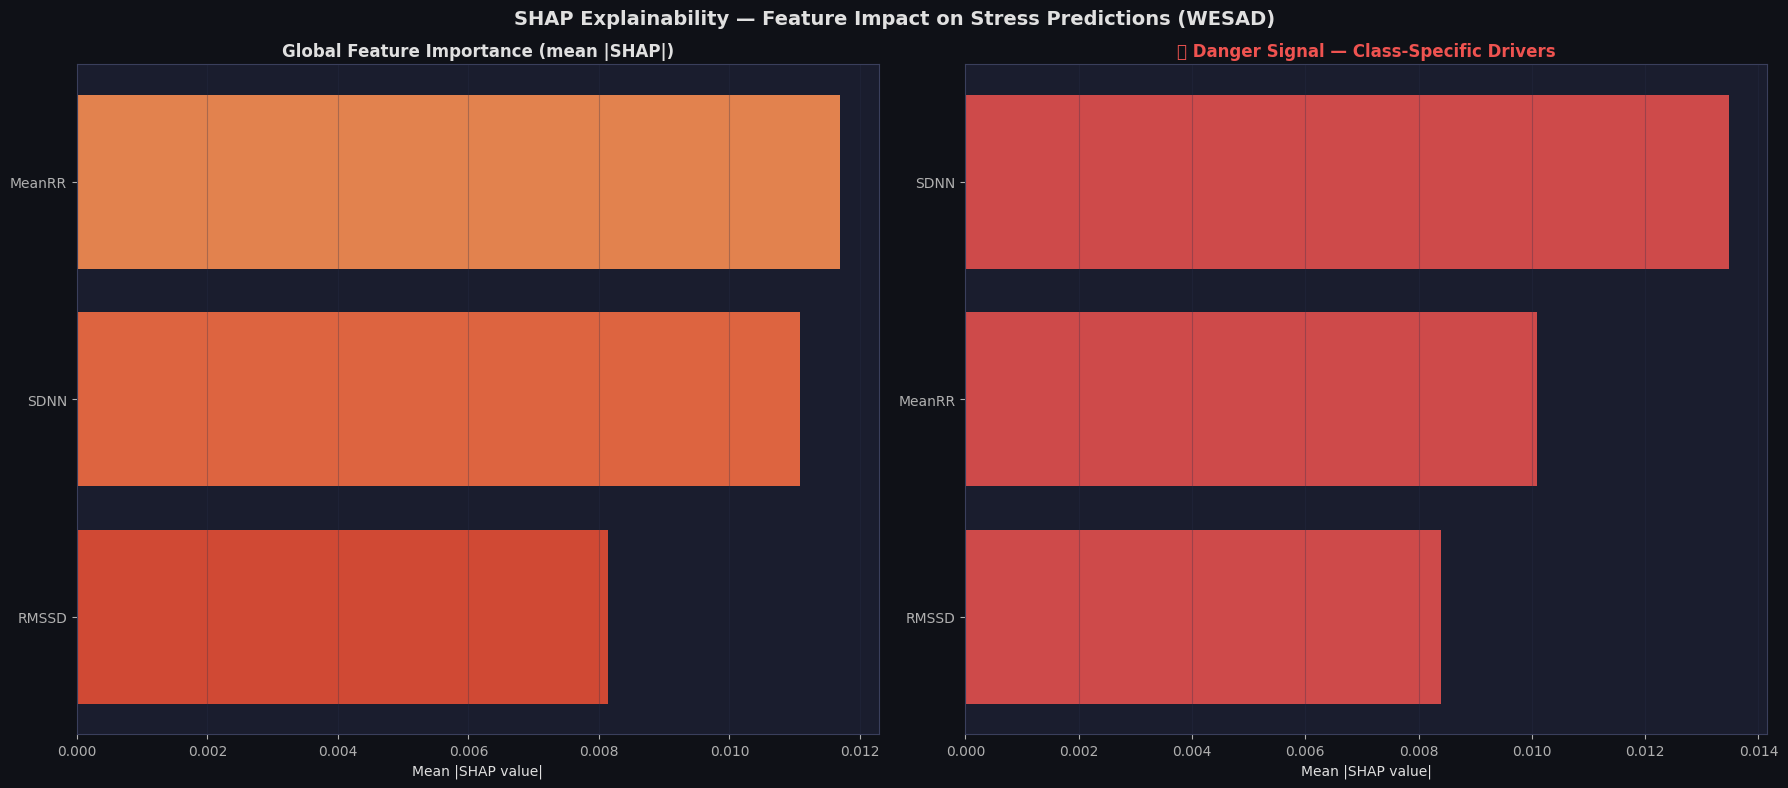

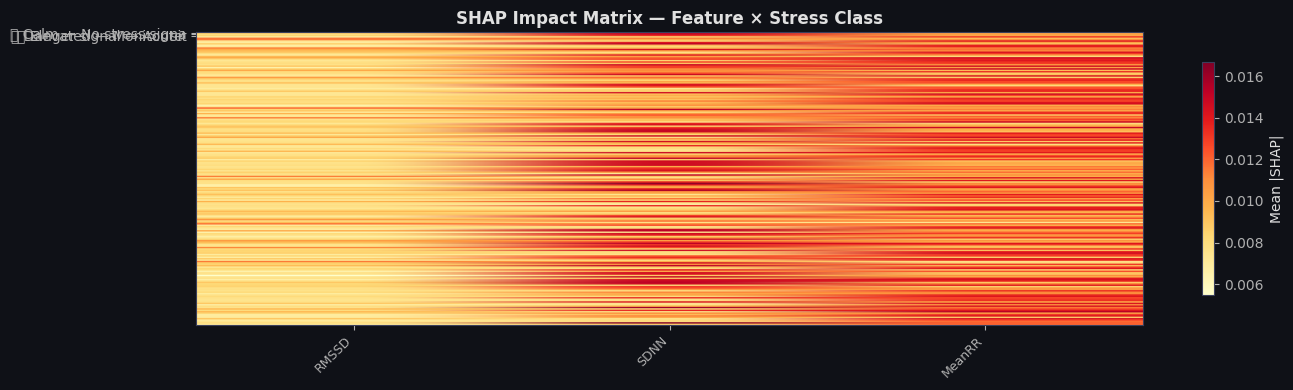

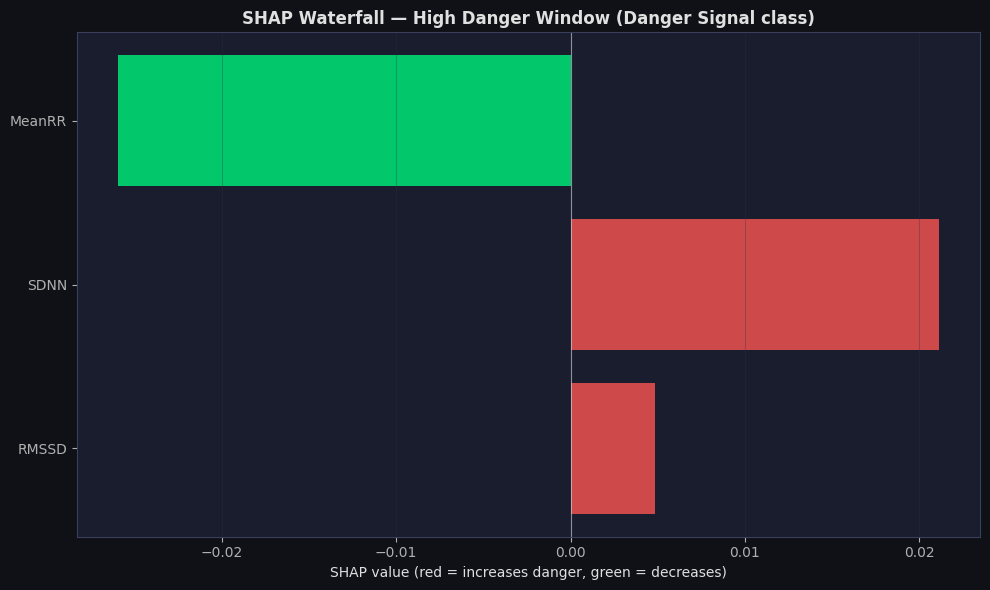

In [24]:
# ── SHAP Explainability ───────────────────────────────────────────────────────
if HAS_SHAP:
    rf_shap = RandomForestClassifier(n_estimators=200, max_depth=10,
                                      class_weight='balanced', random_state=42)
    rf_shap.fit(X_train, y_train)
    explainer  = shap.TreeExplainer(rf_shap)
    shap_vals  = explainer.shap_values(X_test)   # list, one array per class

    feature_names = list(X_hrv_cols)
    n_feat    = len(feature_names)
    n_top     = min(15, n_feat)
    n_top2    = min(12, n_feat)

    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    top_idx   = np.argsort(mean_shap)[-n_top:]
    top_names = [feature_names[i].replace('HRV_','') for i in top_idx]

    # ── Remap shap_vals to only the classes present in y_test ────────────────
    present_classes = sorted(np.unique(np.concatenate([y_train, y_test])))
    n_classes       = len(present_classes)
    class_label_map = {i: CLUSTER_LABELS.get(c, f'Class {c}')
                       for i, c in enumerate(present_classes)}
    class_icon_map  = {i: CLUSTER_ICONS.get(c, '⚪')
                       for i, c in enumerate(present_classes)}

    print(f"   SHAP computed | {n_feat} features | {n_classes} classes: {present_classes}")
    print(f"   Top features : {top_names}")

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('SHAP Explainability — Feature Impact on Stress Predictions (WESAD)',
                 fontsize=14, fontweight='bold')

    # ── Left: global importance ───────────────────────────────────────────────
    colors_shap = plt.cm.RdYlGn(np.linspace(0.85, 0.15, n_top))
    axes[0].barh(top_names, mean_shap[top_idx], color=colors_shap[::-1], alpha=0.9)
    axes[0].set_xlabel('Mean |SHAP value|')
    axes[0].set_title('Global Feature Importance (mean |SHAP|)', fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')

    # ── Right: Danger class specific ─────────────────────────────────────────
    # Find which index in shap_vals corresponds to class 2 (Danger)
    danger_class_idx = present_classes.index(2) if 2 in present_classes else n_classes - 1
    mean_shap_danger = np.abs(shap_vals[danger_class_idx]).mean(axis=0)
    top_idx2         = np.argsort(mean_shap_danger)[-n_top2:]
    top_names2       = [feature_names[i].replace('HRV_','') for i in top_idx2]

    axes[1].barh(top_names2, mean_shap_danger[top_idx2], color='#ef5350', alpha=0.85)
    axes[1].set_xlabel('Mean |SHAP value|')
    axes[1].set_title('🔴 Danger Signal — Class-Specific Drivers',
                       fontweight='bold', color='#ef5350')
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('shap_global.png', dpi=150, bbox_inches='tight', facecolor=DARK)
    plt.show()

    # ── SHAP class × feature heatmap ─────────────────────────────────────────
    shap_matrix = np.array([np.abs(sv).mean(axis=0) for sv in shap_vals])
    top15       = np.argsort(mean_shap)[-n_top:]
    top15_names = [feature_names[i].replace('HRV_','') for i in top15]

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(shap_matrix[:, top15], aspect='auto', cmap='YlOrRd')

    # Force-override locator AFTER imshow to avoid FixedLocator mismatch
    ax.xaxis.set_major_locator(plt.FixedLocator(range(n_top)))
    ax.xaxis.set_major_formatter(plt.FixedFormatter(top15_names))
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    plt.setp(ax.get_xticklabels(), ha='right')

    ax.yaxis.set_major_locator(plt.FixedLocator(range(n_classes)))
    ax.yaxis.set_major_formatter(plt.FixedFormatter(
        [f'{class_icon_map[i]} {class_label_map[i][:22]}' for i in range(n_classes)]
    ))

    ax.set_title('SHAP Impact Matrix — Feature × Stress Class', fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Mean |SHAP|')
    plt.tight_layout()
    plt.savefig('shap_matrix.png', dpi=150, bbox_inches='tight', facecolor=DARK)
    plt.show()

    # ── Waterfall — highest-danger window ────────────────────────────────────
    danger_idx = np.where(y_test == 2)[0]
    if len(danger_idx) > 0:
        pidx    = danger_idx[0]
        sv      = shap_vals[danger_class_idx][pidx]
        n_wfall = min(12, n_feat)
        top_w   = np.argsort(np.abs(sv))[-n_wfall:]
        vals_w  = sv[top_w]
        names_w = [feature_names[i].replace('HRV_','') for i in top_w]

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(names_w, vals_w,
                color=['#ef5350' if v > 0 else '#00e676' for v in vals_w],
                alpha=0.85)
        ax.axvline(0, color='white', lw=0.8, alpha=0.5)
        ax.set_title('SHAP Waterfall — High Danger Window (Danger Signal class)',
                     fontweight='bold')
        ax.set_xlabel('SHAP value (red = increases danger, green = decreases)')
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight', facecolor=DARK)
        plt.show()
    else:
        print("⚠️  No Danger-class windows in test set — skipping waterfall plot")

else:
    print("⚠️ SHAP not available. Install with: pip install shap")

## 📉 Module M8 — Regression: Continuous Danger Score (0–100)
Instead of just 3 stress classes, predict a **continuous danger score**
giving the app a finer signal (e.g. 72/100 triggers a different alert than 45/100).


In [35]:
# ── Regression — Continuous Danger Score (0-100) ─────────────────────────────
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

reg_models = {
    'Ridge':      Ridge(alpha=1.0),
    'Lasso':      Lasso(alpha=0.1, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
}
if HAS_XGB:
    reg_models['XGBoost'] = XGBRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, n_jobs=-1
    )
else:
    reg_models['GradBoost'] = GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_SEED
    )

In [36]:
# ── Regression — Cross-validation ────────────────────────────────────────────
print("📊 Regression — Continuous Danger Score (0-100):")
print("-" * 60)
reg_results = {}

for name, model in reg_models.items():
    r2s   = cross_val_score(model, X_hrv_s, y_severity, cv=5, scoring='r2')
    rmses = np.sqrt(-cross_val_score(model, X_hrv_s, y_severity, cv=5,
                                      scoring='neg_mean_squared_error'))
    reg_results[name] = {'R2': r2s.mean(), 'RMSE': rmses.mean()}
    print(f"  {name:14s}  R²={r2s.mean():.4f} ± {r2s.std():.4f}  "
          f"RMSE={rmses.mean():.2f}")

📊 Regression — Continuous Danger Score (0-100):
------------------------------------------------------------
  Ridge           R²=0.9672 ± 0.0088  RMSE=1.91
  Lasso           R²=0.9667 ± 0.0107  RMSE=1.95
  ElasticNet      R²=0.9535 ± 0.0152  RMSE=2.25
  XGBoost         R²=0.8941 ± 0.0904  RMSE=2.95


In [37]:
# ── Regression — Fit best model & evaluate on test set ───────────────────────
best_reg_name = 'XGBoost' if HAS_XGB else 'GradBoost'
best_reg      = reg_models[best_reg_name]
best_reg.fit(X_train, y_train_sev)
y_pred_sev = best_reg.predict(X_test)

r2_t   = r2_score(y_test_sev, y_pred_sev)
rmse_t = np.sqrt(mean_squared_error(y_test_sev, y_pred_sev))
mae_t  = mean_absolute_error(y_test_sev, y_pred_sev)

print(f"\n✅ {best_reg_name} Test:")
print(f"   R²   = {r2_t:.4f}")
print(f"   RMSE = {rmse_t:.2f}")
print(f"   MAE  = {mae_t:.2f}")


✅ XGBoost Test:
   R²   = 0.9341
   RMSE = 2.65
   MAE  = 1.93


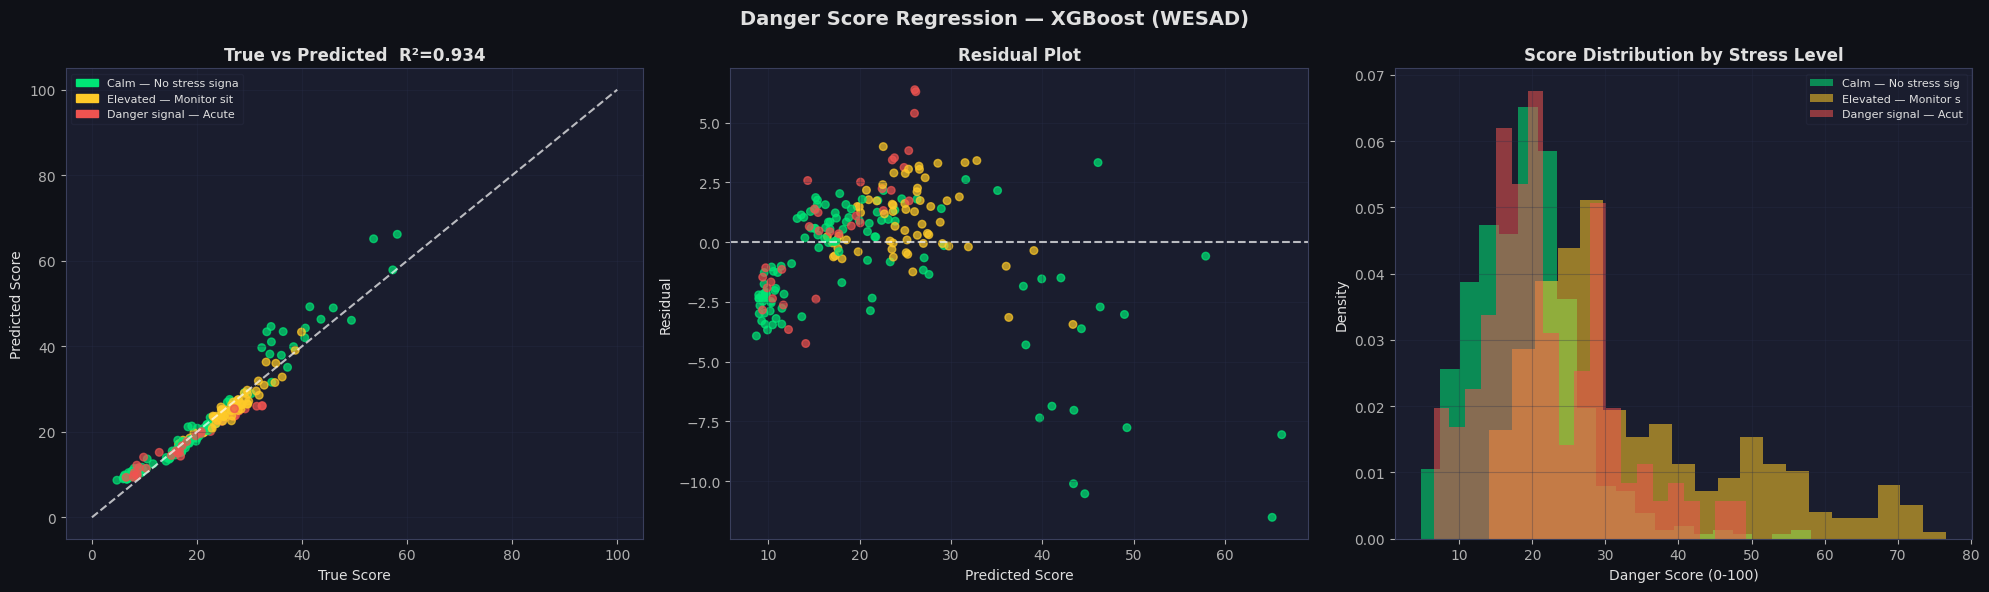

In [38]:
# ── Regression — Scatter & residual plots ────────────────────────────────────
app_col3  = {0:'#00e676', 1:'#ffca28', 2:'#ef5350'}
colors_test = [app_col3[c] for c in y_test]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Danger Score Regression — {best_reg_name} (WESAD)',
             fontsize=14, fontweight='bold')

# True vs Predicted
axes[0].scatter(y_test_sev, y_pred_sev, c=colors_test, alpha=0.7, s=30)
axes[0].plot([0, 100], [0, 100], 'w--', lw=1.5, alpha=0.7)
axes[0].set_xlabel('True Score'); axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'True vs Predicted  R²={r2_t:.3f}', fontweight='bold')
patches = [mpatches.Patch(color=app_col3[i], label=CLUSTER_LABELS[i][:22])
           for i in range(3)]
axes[0].legend(handles=patches, fontsize=8, framealpha=0.2)
axes[0].grid(True, alpha=0.3)

# Residuals
axes[1].scatter(y_pred_sev, y_test_sev - y_pred_sev, c=colors_test, alpha=0.7, s=30)
axes[1].axhline(0, color='white', lw=1.5, linestyle='--', alpha=0.7)
axes[1].set_xlabel('Predicted Score'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Score distribution by class
for lbl, color in app_col3.items():
    mask = y_app == lbl
    axes[2].hist(y_severity[mask], bins=20, alpha=0.55, color=color,
                 label=CLUSTER_LABELS[lbl][:20], density=True)
axes[2].set_xlabel('Danger Score (0-100)'); axes[2].set_ylabel('Density')
axes[2].set_title('Score Distribution by Stress Level', fontweight='bold')
axes[2].legend(fontsize=8, framealpha=0.2)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regression_results.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()

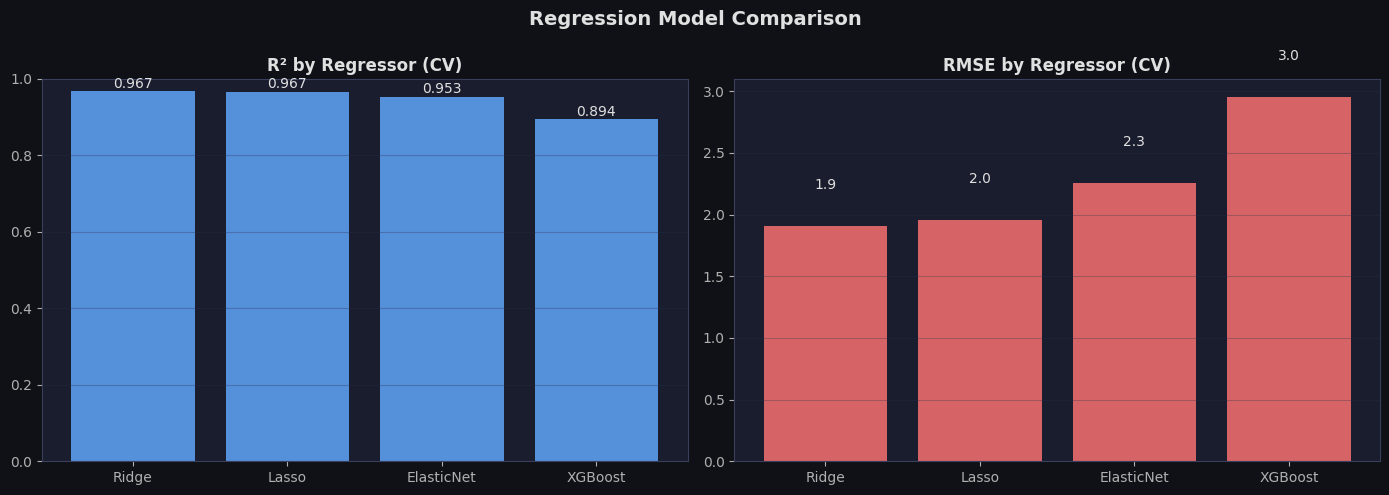

In [39]:
# ── Regression — Model comparison bar charts ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regression Model Comparison', fontsize=14, fontweight='bold')

names_r   = list(reg_results.keys())
r2_vals   = [reg_results[n]['R2']   for n in names_r]
rmse_vals = [reg_results[n]['RMSE'] for n in names_r]

axes[0].bar(names_r, r2_vals, color='#60a5fa', alpha=0.85)
axes[0].set_title('R² by Regressor (CV)', fontweight='bold')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_vals):
    axes[0].text(i, max(v, 0) + 0.01, f'{v:.3f}', ha='center', fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(names_r, rmse_vals, color='#f87171', alpha=0.85)
axes[1].set_title('RMSE by Regressor (CV)', fontweight='bold')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('regression_comparison.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()

## 🧬 Module M9 — Deep Learning: 1D-CNN + Transformer on Raw BVP

✅ HRV Transformer-CNN (ECG) | params: 177,539 | device: cuda
  Epoch   5/30 | loss=0.9448 | val_acc=0.6095
  Epoch  10/30 | loss=0.8860 | val_acc=0.6619
  Epoch  15/30 | loss=0.8333 | val_acc=0.6952
  Epoch  20/30 | loss=0.7921 | val_acc=0.6952
  Epoch  25/30 | loss=0.8090 | val_acc=0.7143
  Epoch  30/30 | loss=0.7798 | val_acc=0.7238

✅ Final validation accuracy: 0.7238


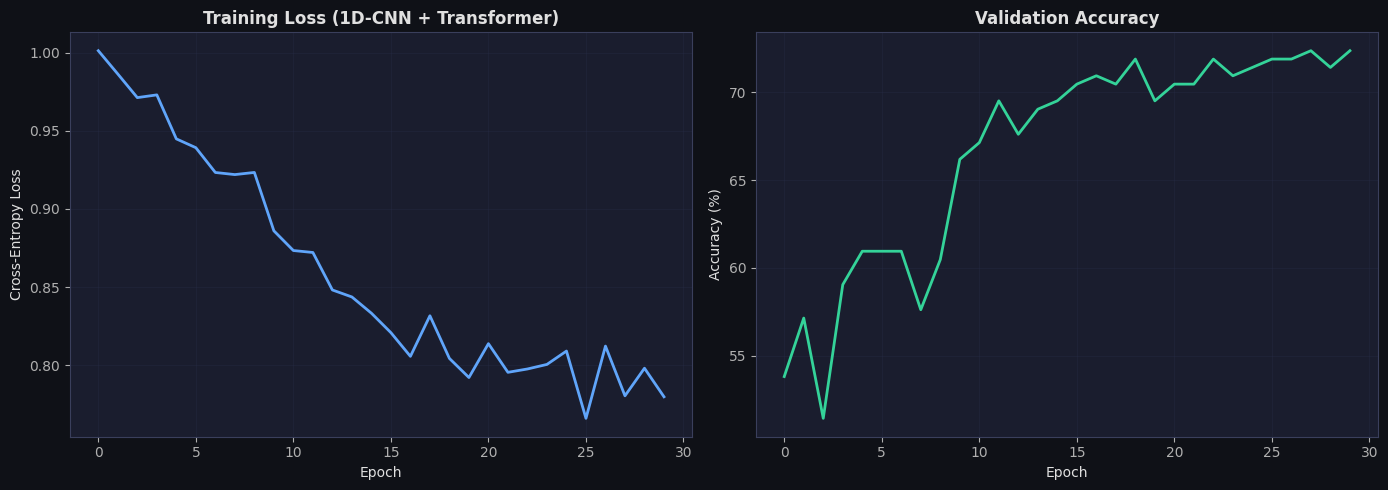

In [43]:
if HAS_TORCH:
    # ── Pad/truncate ECG windows to fixed length ──────────────────────────────
    SEQ_LEN = 256

    def prep_ecg(w, length=SEQ_LEN):
        arr = np.array(w, dtype=np.float32)
        mu, sigma = arr.mean(), arr.std() + 1e-9
        arr = (arr - mu) / sigma
        if len(arr) >= length:
            return arr[:length]
        return np.pad(arr, (0, length - len(arr)), mode='edge')

    X_seq = np.stack([prep_ecg(e) for e in all_ecg], axis=0)[:, :, np.newaxis]  # (N, SEQ_LEN, 1)
    y_seq = y_app.copy()

    Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
        X_seq, y_seq, test_size=0.2, stratify=y_seq, random_state=RANDOM_SEED
    )

    # ── Dataset & Loader ──────────────────────────────────────────────────────
    def make_loader(X, y, shuffle=True, bs=32):
        ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
        return DataLoader(ds, batch_size=bs, shuffle=shuffle)

    train_loader = make_loader(Xs_tr, ys_tr)
    test_loader  = make_loader(Xs_te, ys_te, shuffle=False)

    # ── Model: 1D-CNN + Transformer ───────────────────────────────────────────
    class HRVTransformerCNN(nn.Module):
        def __init__(self, seq_len=SEQ_LEN, d_model=64, nhead=4,
                     num_layers=3, n_classes=3, dropout=0.3):
            super().__init__()
            self.cnn = nn.Sequential(
                nn.Conv1d(1,   32, kernel_size=7, padding=3), nn.GELU(), nn.BatchNorm1d(32),
                nn.Conv1d(32,  64, kernel_size=5, padding=2), nn.GELU(), nn.BatchNorm1d(64),
                nn.Conv1d(64, d_model, kernel_size=3, padding=1), nn.GELU(),
                nn.AdaptiveAvgPool1d(64)
            )
            pe = torch.zeros(1, 64, d_model)
            pos = torch.arange(64).unsqueeze(1).float()
            div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
            pe[0, :, 0::2] = torch.sin(pos * div)
            pe[0, :, 1::2] = torch.cos(pos * div[:d_model // 2])
            self.register_buffer('pe', pe)
            enc_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead, dim_feedforward=256,
                dropout=dropout, batch_first=True, activation='gelu'
            )
            self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
            self.norm = nn.LayerNorm(d_model)
            self.head = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(d_model, 64), nn.GELU(),
                nn.Linear(64, n_classes)
            )

        def forward(self, x):           # x: (B, L, 1)
            x = x.permute(0, 2, 1)     # → (B, 1, L)
            x = self.cnn(x)            # → (B, d_model, 64)
            x = x.permute(0, 2, 1)     # → (B, 64, d_model)
            x = x + self.pe
            x = self.transformer(x)    # → (B, 64, d_model)
            x = self.norm(x.mean(dim=1))
            return self.head(x)

    dl_model  = HRVTransformerCNN().to(DEVICE)
    optimizer = optim.AdamW(dl_model.parameters(), lr=3e-4, weight_decay=1e-4)  # ← dl_model not model
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    criterion = nn.CrossEntropyLoss(
        weight=torch.FloatTensor([1.0, 1.2, 1.0]).to(DEVICE)
    )

    total_params = sum(p.numel() for p in dl_model.parameters() if p.requires_grad)
    print(f"✅ HRV Transformer-CNN (ECG) | params: {total_params:,} | device: {DEVICE}")

    # ── Training loop ─────────────────────────────────────────────────────────
    EPOCHS = 30
    train_losses, val_accs = [], []

    for epoch in range(EPOCHS):
        dl_model.train()                                      # ← dl_model not model
        epoch_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(dl_model(Xb), yb)               # ← dl_model not dl_dl_model
            loss.backward()
            nn.utils.clip_grad_norm_(dl_model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()

        dl_model.eval()                                       # ← dl_model not model
        correct = total = 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                preds = dl_model(Xb.to(DEVICE)).argmax(dim=1).cpu()  # ← dl_model
                correct += (preds == yb).sum().item()
                total   += len(yb)
        acc = correct / total
        train_losses.append(epoch_loss / len(train_loader))
        val_accs.append(acc)
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d}/{EPOCHS} | "
                  f"loss={train_losses[-1]:.4f} | val_acc={acc:.4f}")

    print(f"\n✅ Final validation accuracy: {val_accs[-1]:.4f}")

    
    # ── Training curves ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(train_losses, color='#60a5fa', lw=2)
    axes[0].set_title('Training Loss (1D-CNN + Transformer)', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot([v * 100 for v in val_accs], color='#34d399', lw=2)
    axes[1].set_title('Validation Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('dl_training.png', dpi=150, bbox_inches='tight', facecolor=DARK)
    plt.show()

else:
    print("⚠️  PyTorch not available. Install with: pip install torch")

## 📅 Module M10 — Longitudinal Trajectory (LSTM)

Using device: cuda
Dataset: (200, 6, 6)

Accuracy: 0.4
                 precision    recall  f1-score   support

   🟢 Recovering       0.00      0.00      0.00         7
       ⚪ Stable       0.41      1.00      0.58        16
🔴 Deteriorating       0.00      0.00      0.00        17

       accuracy                           0.40        40
      macro avg       0.14      0.33      0.19        40
   weighted avg       0.16      0.40      0.23        40



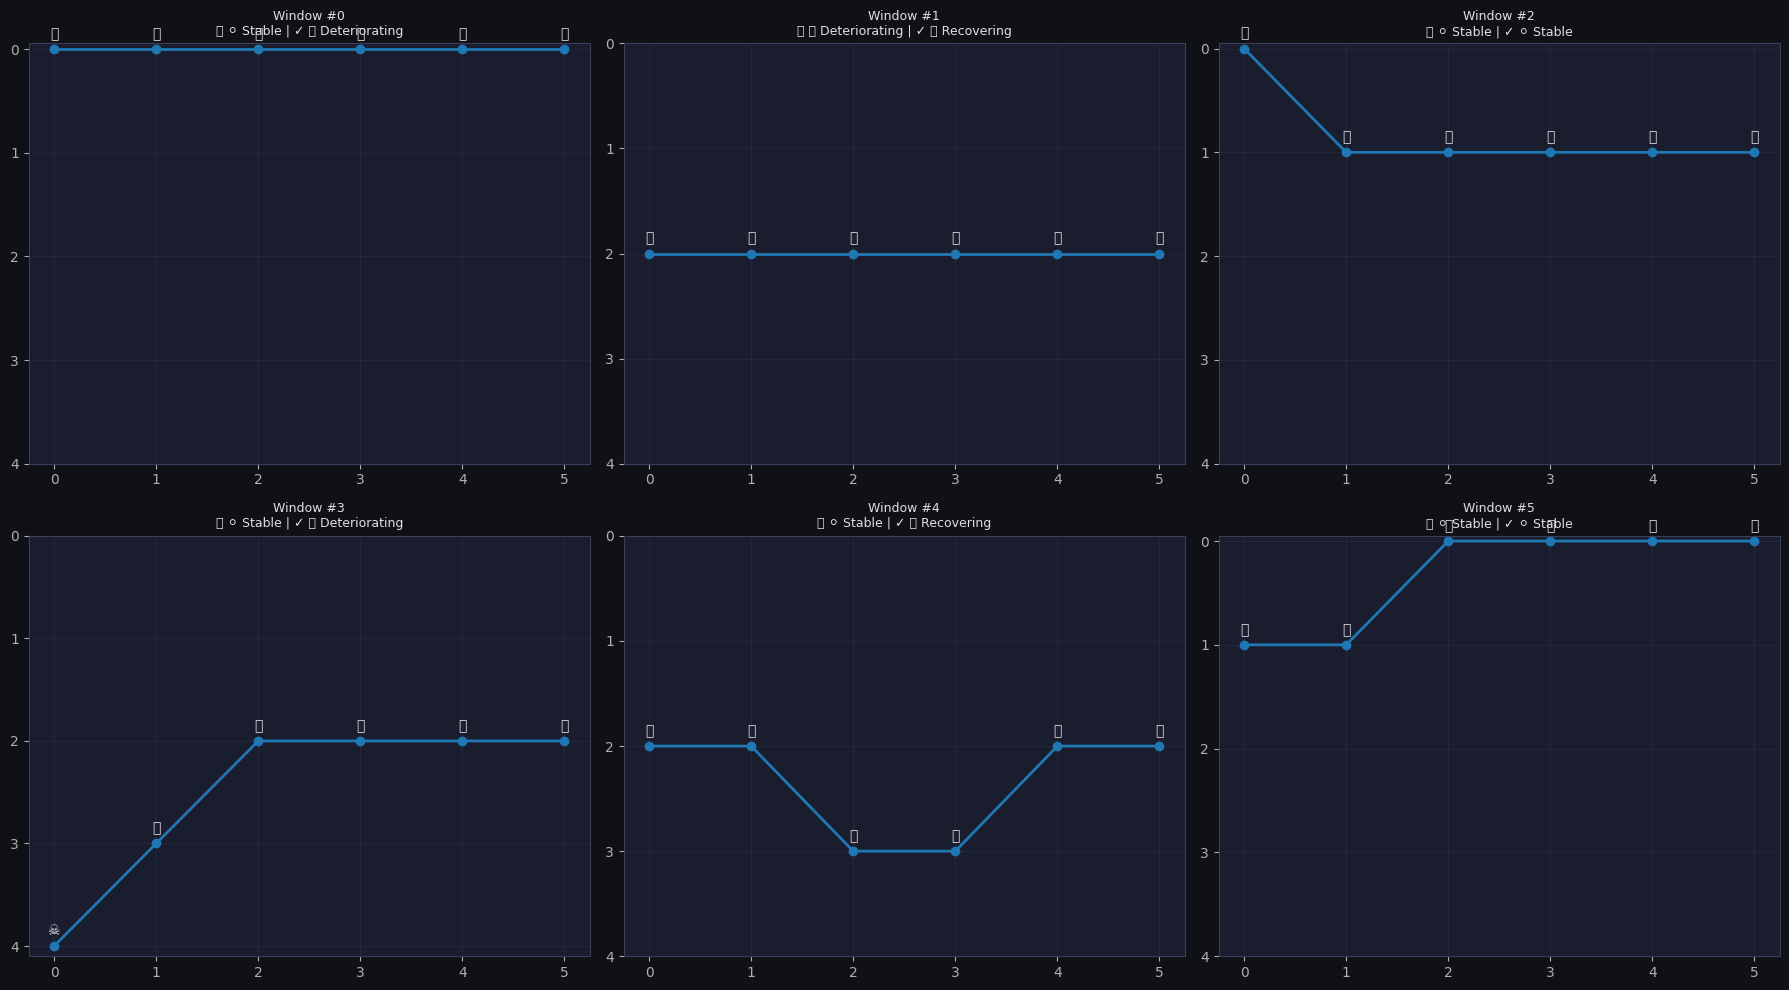

In [44]:
# ── FULL SELF-CONTAINED CELL ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Torch
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", DEVICE)

# ── CONFIG ───────────────────────────────────────────────────────────────
N_LONG = 200
TIME_STEPS = 6
N_FEATURES = 6

TRAJ_LABELS = {0:'🟢 Recovering', 1:'⚪ Stable', 2:'🔴 Deteriorating'}
# Using global CLUSTER_LABELS and CLUSTER_ICONS defined in Cell 1

# ── SIMULATE TRAJECTORIES ────────────────────────────────────────────────
def recovery_trajectory(start_cluster, n_timepoints=6):
    traj = [start_cluster]
    for _ in range(n_timepoints - 1):
        c = traj[-1]
        p_improve  = [0.05, 0.15, 0.25, 0.35, 0.40][c]
        p_worsen   = [0.02, 0.05, 0.10, 0.05, 0.00][c]
        r = np.random.random()

        if r < p_improve and c > 0:
            traj.append(c - 1)
        elif r < p_improve + p_worsen and c < 4:
            traj.append(c + 1)
        else:
            traj.append(c)
    return traj

def trajectory_label(traj):
    delta = traj[-1] - traj[0]
    if delta < -1: return 0
    elif delta == 0: return 1
    else: return 2

trajectories, labels = [], []
for i in range(N_LONG):
    start = np.random.randint(0, 5)
    traj = recovery_trajectory(start)
    trajectories.append(traj)
    labels.append(trajectory_label(traj))

# ── FAKE FEATURE EXTRACTION (FAST) ───────────────────────────────────────
X = []
for traj in trajectories:
    seq = []
    for c in traj:
        # simulate 6 features per timestep
        seq.append([
            np.random.normal(50 - c*5, 5),
            np.random.normal(30 - c*3, 5),
            np.random.normal(80 + c*5, 5),
            np.random.normal(1 + c*0.2, 0.2),
            np.random.normal(0.5 + c*0.1, 0.1),
            np.random.normal(10 + c*2, 2)
        ])
    X.append(seq)

X = np.array(X, dtype=np.float32)
y = np.array(labels)

# Normalize
X = (X - X.mean()) / (X.std() + 1e-9)

print("Dataset:", X.shape)

# ── LSTM MODEL ──────────────────────────────────────────────────────────
class TrajectoryLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(6, 64, 2, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(128, 1)
        self.fc = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        w = torch.softmax(self.attn(out).squeeze(-1), dim=1)
        ctx = (out * w.unsqueeze(-1)).sum(dim=1)
        return self.fc(ctx)

# Split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y)

# Train
lstm_model = TrajectoryLSTM().to(DEVICE)
opt = optim.Adam(lstm_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

X_tr_t = torch.tensor(X_tr).to(DEVICE)
y_tr_t = torch.tensor(y_tr).to(DEVICE)

for epoch in range(20):
    lstm_model.train()
    opt.zero_grad()
    loss = crit(lstm_model(X_tr_t), y_tr_t)
    loss.backward()
    opt.step()

# Evaluate
lstm_model.eval()
with torch.no_grad():
    preds = lstm_model(torch.tensor(X_te).to(DEVICE)).argmax(dim=1).cpu().numpy()

print("\nAccuracy:", (preds == y_te).mean())
print(classification_report(y_te, preds, target_names=list(TRAJ_LABELS.values())))

# ── VISUALIZATION ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, idx in zip(axes.flatten(), range(6)):
    traj_vals = trajectories[idx]

    pred_lbl = TRAJ_LABELS[preds[idx]] if idx < len(preds) else 'N/A'
    true_lbl = TRAJ_LABELS[y_te[idx]] if idx < len(y_te) else 'N/A'

    ax.plot(traj_vals, 'o-', lw=2)

    for t, v in enumerate(traj_vals):
        ax.annotate(CLUSTER_ICONS[v], (t, v),
                    textcoords='offset points', xytext=(0,8),
                    ha='center')

    ax.set_title(f'Window #{idx}\n🔮 {pred_lbl} | ✓ {true_lbl}', fontsize=9)

    ax.set_yticks(range(5))
    ax.set_xticks(range(6))
    ax.invert_yaxis()
    ax.grid(True)

plt.tight_layout()
plt.show()

## 📐 Module M11 — Calibration & Uncertainty

   Classes present: [np.int64(0), np.int64(1), np.int64(2)]  (3 total)
   Proba shape — calibrated: (209, 3)  raw: (209, 3)


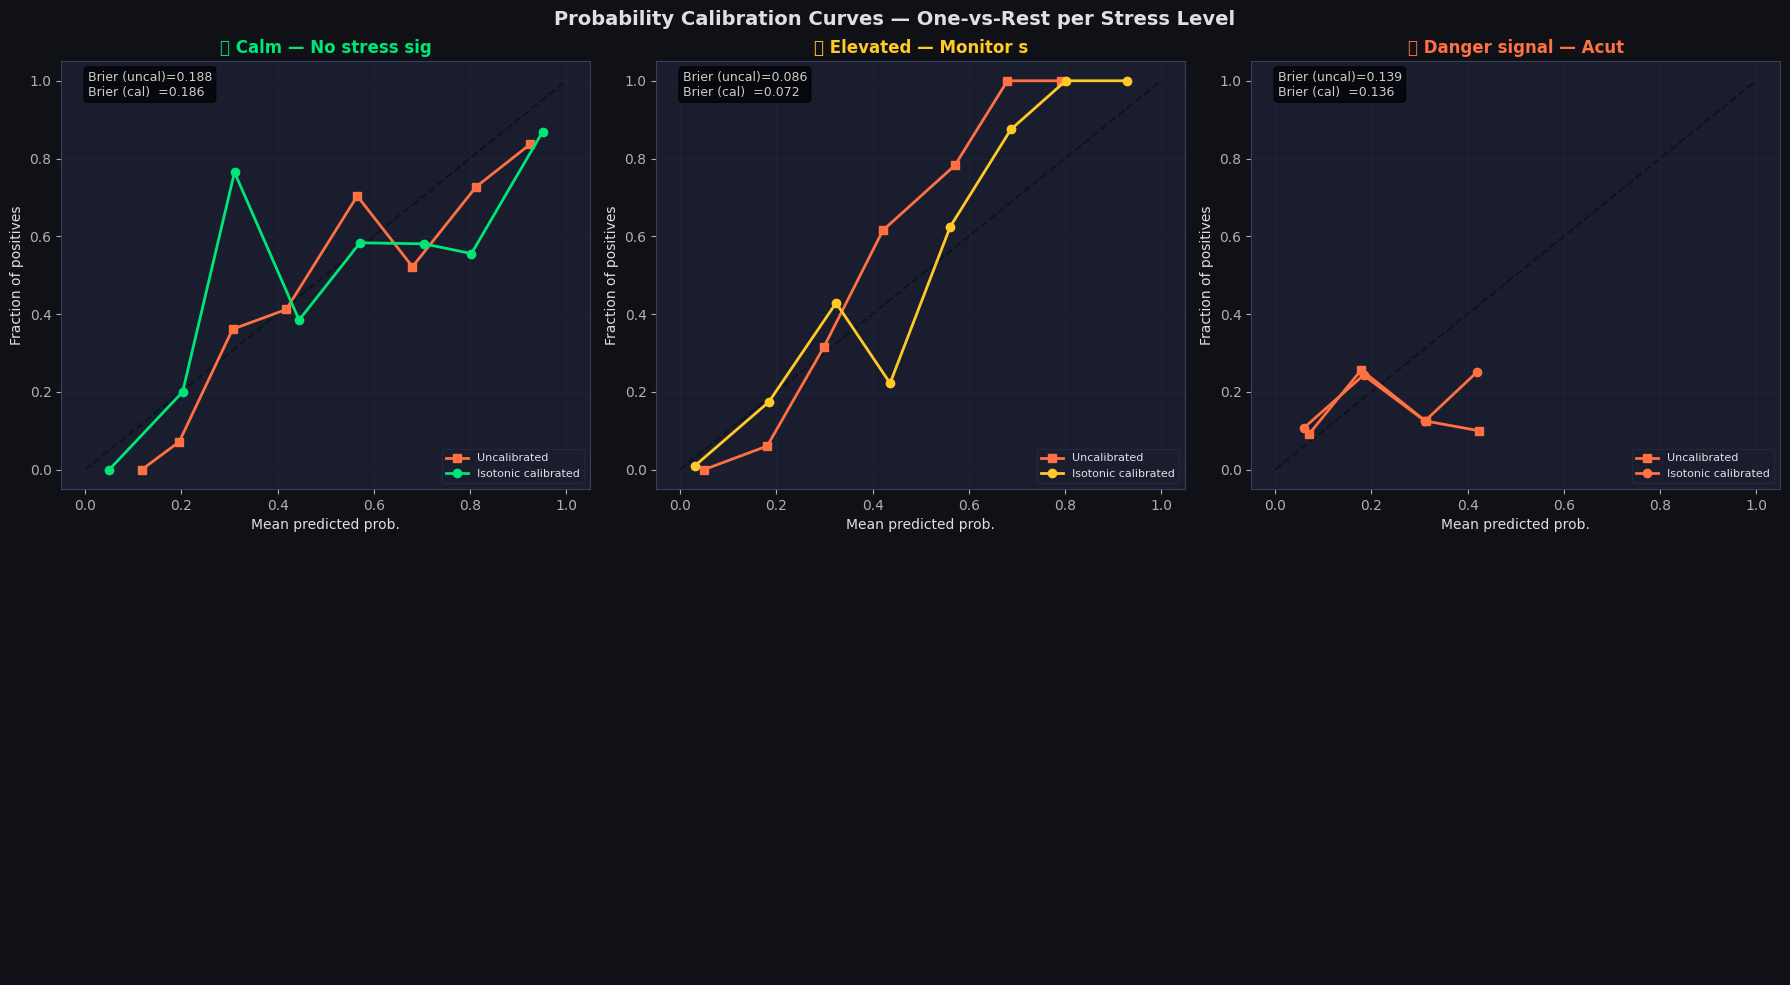


🎯 Uncertainty-aware predictions:
------------------------------------------------------------
P0: True=🟢 Pred=🟢 ✓ Conf=0.782 Unc=0.624
   {'🟢': np.float64(0.782), '🟡': np.float64(0.038), '🔴': np.float64(0.18)}
P1: True=🟢 Pred=🟡 ✗ Conf=0.455 Unc=1.025
   {'🟢': np.float64(0.378), '🟡': np.float64(0.455), '🔴': np.float64(0.167)}
P2: True=🟢 Pred=🟡 ✗ Conf=0.435 Unc=1.074
   {'🟢': np.float64(0.307), '🟡': np.float64(0.435), '🔴': np.float64(0.258)}
P3: True=🟢 Pred=🟡 ✗ Conf=0.365 Unc=1.091
   {'🟢': np.float64(0.277), '🟡': np.float64(0.365), '🔴': np.float64(0.358)}
P4: True=🟢 Pred=🟡 ✗ Conf=0.393 Unc=1.077
   {'🟢': np.float64(0.238), '🟡': np.float64(0.393), '🔴': np.float64(0.368)}


In [46]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import label_binarize

# ── Derive actual classes from data (don't rely on N_CLASSES) ─────────────────
present_classes = sorted(np.unique(np.concatenate([y_train, y_test])))
n_cal_classes   = len(present_classes)
print(f"   Classes present: {present_classes}  ({n_cal_classes} total)")

# ── CALIBRATED MODEL ──────────────────────────────────────────────────────────
calibrated_clf = CalibratedClassifierCV(
    estimator=RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ),
    method='isotonic',
    cv=5
)
calibrated_clf.fit(X_train, y_train)
y_proba_cal = calibrated_clf.predict_proba(X_test)

# ── UNCALIBRATED MODEL ────────────────────────────────────────────────────────
rf_raw = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf_raw.fit(X_train, y_train)
p_raw_all = rf_raw.predict_proba(X_test)

print(f"   Proba shape — calibrated: {y_proba_cal.shape}  raw: {p_raw_all.shape}")

# ── CALIBRATION CURVES ────────────────────────────────────────────────────────
ncols    = min(3, n_cal_classes)
nrows    = int(np.ceil(n_cal_classes / ncols)) + 1   # +1 row for possible empty cell
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes      = np.array(axes).flatten()                 # always 1-D for easy indexing

fig.suptitle(
    'Probability Calibration Curves — One-vs-Rest per Stress Level',
    fontsize=14, fontweight='bold'
)

y_test_bin = label_binarize(y_test, classes=present_classes)
if n_cal_classes == 2:                               # label_binarize returns (N,1) for binary
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

for idx, cls in enumerate(present_classes):
    ax    = axes[idx]
    p_raw = p_raw_all[:, idx]
    p_cal = y_proba_cal[:, idx]

    frac_raw, mean_raw = calibration_curve(y_test_bin[:, idx], p_raw,
                                            n_bins=8, strategy='uniform')
    frac_cal, mean_cal = calibration_curve(y_test_bin[:, idx], p_cal,
                                            n_bins=8, strategy='uniform')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.plot(mean_raw, frac_raw, 's-', color='#ff7043', lw=2, ms=6, label='Uncalibrated')
    ax.plot(mean_cal, frac_cal, 'o-', color=CLUSTER_COLORS[cls], lw=2, ms=6,
            label='Isotonic calibrated')

    bs_raw = brier_score_loss(y_test_bin[:, idx], p_raw)
    bs_cal = brier_score_loss(y_test_bin[:, idx], p_cal)

    ax.set_title(
        f'{CLUSTER_ICONS[cls]} {CLUSTER_LABELS[cls][:20]}',
        fontweight='bold', color=CLUSTER_COLORS[cls]
    )
    ax.set_xlabel('Mean predicted prob.')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=8, framealpha=0.3)
    ax.text(
        0.05, 0.92,
        f'Brier (uncal)={bs_raw:.3f}\nBrier (cal)  ={bs_cal:.3f}',
        transform=ax.transAxes, fontsize=9, color='#ccc',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7)
    )
    ax.grid(True, alpha=0.3)

# Hide any unused subplot axes
for ax in axes[n_cal_classes:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()

# ── PREDICTION WITH UNCERTAINTY ───────────────────────────────────────────────
def predict_with_uncertainty(X_new, clf):
    proba       = clf.predict_proba(X_new.reshape(1, -1))[0]
    pred_class  = present_classes[np.argmax(proba)]   # map back to actual class label
    confidence  = proba.max()
    uncertainty = -np.sum(proba * np.log(proba + 1e-9))
    return pred_class, confidence, uncertainty, proba

print("\n🎯 Uncertainty-aware predictions:")
print("-" * 60)
for i in range(min(5, len(X_test))):
    c, conf, unc, proba = predict_with_uncertainty(X_test[i], calibrated_clf)
    true  = y_test[i]
    match = '✓' if c == true else '✗'
    print(
        f"P{i}: True={CLUSTER_ICONS[true]} Pred={CLUSTER_ICONS[c]} {match} "
        f"Conf={conf:.3f} Unc={unc:.3f}"
    )
    print("  ", dict(zip([CLUSTER_ICONS[k] for k in present_classes], proba.round(3))))